# Job Candidate Prediction

## Objective

I was tasked by a tech company to create a machine learning model to help them predict whether or not potential job candidates are interested in taking a new job.

## Data Dictionary

Data Dictionary:
- enrollee_id: Unique ID for the candidate
- city: City code
- city_ development _index: Development index of the city (scaled)
- gender: Gender of the candidate
- relevent_experience: Relevant experience of the candidate in years
- enrolled_university: Type of University course enrolled if any
- education_level: Education level of candidate
- major_discipline: Education major discipline of the candidate
- experience: Candidate total experience in years
- company_size: No of employees in current employer's company
- company_type: Type of current employer
- lastnewjob: Difference in years between previous job and current job
- training_hours: training hours completed
- target: 0 – Not looking for a job change, 1 – Looking for a job change

## Load libraries

In [397]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [398]:
#Load the csv file
df = pd.read_csv("job_candidates.csv") 

In [399]:
#make a copy of the original data
OriginalData = df.copy()

## Data Overview

In [400]:
#Get a sample of our data
df.sample(10) 

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19148,9212,city_21,0.624,NaN,Has relevent experience,no_enrollment,Masters,STEM,3,100-500,Pvt Ltd,3,40,1.0
4965,8183,city_45,0.890,NaN,Has relevent experience,no_enrollment,Graduate,STEM,16,500-999,Pvt Ltd,1,4,0.0
18639,15262,city_160,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,9,10/49,Funded Startup,2,18,0.0
3787,3613,city_16,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,14,<10,Funded Startup,1,42,0.0
913,11696,city_114,0.926,Male,Has relevent experience,no_enrollment,Masters,STEM,15,NaN,NGO,1,77,0.0
16642,8140,city_21,0.624,NaN,Has relevent experience,no_enrollment,Masters,STEM,<1,100-500,Pvt Ltd,1,53,0.0
11775,1941,city_21,0.624,Male,No relevent experience,Full time course,High School,NaN,5,NaN,Pvt Ltd,never,14,1.0
1764,23642,city_11,0.550,Male,No relevent experience,no_enrollment,Graduate,STEM,5,NaN,NaN,never,37,1.0
1341,1922,city_19,0.682,Male,Has relevent experience,no_enrollment,Graduate,STEM,9,10000+,Pvt Ltd,>4,88,1.0
14212,21484,city_11,0.550,NaN,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,1,10,0.0


In [401]:
df.shape

(19158, 14)

In [402]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

Observations:
- We have a large data set with 8 columns that have missing data.
- most of our data types are objects, with some floats and ints.
- enrollee_id does not seem to have value to our model.

In [403]:
# Check for duplicate values in the data
df.duplicated().sum()

0

Observation:
- There are no duplicate values in our data.

In [404]:
#This finds the number of null values for each of the columns
df.isna().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

Observation:
- there is a lot of missing data
- some of these may be correlated and we should look at the rows as a whole not just columns when dealing with missing values.

In [405]:
#Returns the number of unique values in each column
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64

Observation:
- looks like gender has inconsistant data
- all of these columns will need further inspection.

In [406]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


Observation:
- enrollee_id should be dropped to clear up the data
- city_development-index seems like it is already min/max scaled
- training_hours might have outliers we need to look at

In [407]:
df = df.drop(['enrollee_id'], axis=1)

In [408]:
df.sample(10)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
15126,city_103,0.920,NaN,No relevent experience,no_enrollment,High School,NaN,4,NaN,NaN,never,23,0.0
2929,city_98,0.949,Male,Has relevent experience,no_enrollment,Masters,Other,>20,500-999,Pvt Ltd,2,14,0.0
10467,city_100,0.887,Male,Has relevent experience,no_enrollment,High School,NaN,3,NaN,NaN,1,91,0.0
16568,city_136,0.897,Male,No relevent experience,no_enrollment,Phd,STEM,>20,500-999,Public Sector,>4,22,0.0
4583,city_67,0.855,Male,Has relevent experience,no_enrollment,Masters,STEM,7,NaN,NaN,1,112,0.0
3557,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,4,NaN,NaN,1,96,1.0
4161,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,STEM,10,500-999,Pvt Ltd,1,126,0.0
3570,city_21,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,9,10/49,Pvt Ltd,>4,24,1.0
3280,city_116,0.743,NaN,No relevent experience,no_enrollment,Masters,Humanities,2,NaN,NaN,1,198,1.0
16617,city_36,0.893,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,<10,Early Stage Startup,1,27,0.0


## Data Preprocessing

### Duplicate Data

We known from our data overview that ther are no duplicate data in our set

### Missing Values

In [409]:
#See the amount of null values for each of the columns
df.isna().sum()

city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

Observations: Data with missing values that needs to be looked at:
- gender
- enrolled_university
- education_level
- major_discipline
- experience
- company_size
- company_type
- last_new_job

In [410]:
df["gender"].isna().sum()

4508

In [411]:
df.gender.describe().T

count     14650
unique        3
top        Male
freq      13221
Name: gender, dtype: object

In [412]:
#Replace with unknown and come back to it due to the large amount of missing data.
df['gender'] = df['gender'].replace(np.nan, 'Unknown') 

In [413]:
df["gender"].isna().sum()# no null values left 

0

In [414]:
df["enrolled_university"].isna().sum()

386

In [415]:
df.enrolled_university.describe().T

count             18772
unique                3
top       no_enrollment
freq              13817
Name: enrolled_university, dtype: object

In [416]:
#Replace with mode because it is categorical, and there is not very many missing values
df['enrolled_university'] = df['enrolled_university'].replace(np.nan, 'no_enrollment') 

In [417]:
df["enrolled_university"].isna().sum()# no null values left 

0

In [418]:
df["education_level"].isna().sum()

460

In [419]:
df.education_level.describe().T

count        18698
unique           5
top       Graduate
freq         11598
Name: education_level, dtype: object

In [420]:
#Replace with mode because it is categorical, and there is not very many missing values
df['education_level'] = df['education_level'].replace(np.nan, 'Graduate') 

In [421]:
df["education_level"].isna().sum()#no null values

0

In [422]:
df["major_discipline"].isna().sum()

2813

In [423]:
df.major_discipline.describe().T

count     16345
unique        6
top        STEM
freq      14492
Name: major_discipline, dtype: object

In [424]:
df['major_discipline'] = df['major_discipline'].replace(np.nan, 'Unknown') 

In [425]:
df["major_discipline"].isna().sum()

0

In [426]:
df["experience"].isna().sum()

65

In [427]:
df.experience.describe().T

count     19093
unique       22
top         >20
freq       3286
Name: experience, dtype: object

In [428]:
df['experience'] = df['experience'].replace(np.nan, '>20') 

In [429]:
df["experience"].isna().sum()

0

In [430]:
df["company_size"].isna().sum()

5938

In [431]:
df.company_size.describe().T

count     13220
unique        8
top       50-99
freq       3083
Name: company_size, dtype: object

In [432]:
df['company_size'] = df['company_size'].replace(np.nan, 'Unknown') 

In [433]:
df["company_size"].isna().sum()

0

In [434]:
df["company_type"].isna().sum()

6140

In [435]:
df.company_type.describe().T

count       13018
unique          6
top       Pvt Ltd
freq         9817
Name: company_type, dtype: object

In [436]:
df['company_type'] = df['company_type'].replace(np.nan, 'Unknown') 

In [437]:
df["company_type"].isna().sum()

0

In [438]:
df["last_new_job"].isna().sum()

423

In [439]:
df.last_new_job.describe().T

count     18735
unique        6
top           1
freq       8040
Name: last_new_job, dtype: object

In [440]:
df['last_new_job'] = df['last_new_job'].replace(np.nan, '1') 

In [441]:
df["last_new_job"].isna().sum()

0

### Inconsistent Data

In [442]:
df.dtypes

city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [443]:
#Look at values
df['city'].value_counts() 

city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_129       3
city_111       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64

In [444]:
#Look at values
df['city_development_index'].value_counts() 

city_development_index
0.920    5200
0.624    2702
0.910    1533
0.926    1336
0.698     683
         ... 
0.649       4
0.807       4
0.781       3
0.625       3
0.664       1
Name: count, Length: 93, dtype: int64

In [445]:
#Look at values
df['gender'].value_counts() 

gender
Male       13221
Unknown     4508
Female      1238
Other        191
Name: count, dtype: int64

In [446]:
#Look at values
df['relevent_experience'].value_counts() 

relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: count, dtype: int64

In [447]:
#Look at values
df['enrolled_university'].value_counts() 

enrolled_university
no_enrollment       14203
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [448]:
#Look at values
df['education_level'].value_counts() 

education_level
Graduate          12058
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [449]:
#Look at values
df['major_discipline'].value_counts() 

major_discipline
STEM               14492
Unknown             2813
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

In [450]:
#Look at values
df['experience'].value_counts() 

experience
>20    3351
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
Name: count, dtype: int64

In [451]:
#make data consistent
df.loc[df['experience'] == '>20', ['experience']] = '21'
df.loc[df['experience'] == '<1', ['experience']] = '0'

In [452]:
df['experience'].value_counts() 

experience
21    3351
5     1430
4     1403
3     1354
6     1216
2     1127
7     1028
10     985
9      980
8      802
15     686
11     664
14     586
1      549
0      522
16     508
12     494
13     399
17     342
19     304
18     280
20     148
Name: count, dtype: int64

In [453]:
#Look at values
df['company_size'].value_counts() 

company_size
Unknown      5938
50-99        3083
100-500      2571
10000+       2019
10/49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

In [454]:
# update the unique column names to match the other data
df.loc[df['company_size'] == '10000+', ['company_size']] = '>10000'
df.loc[df['company_size'] == '10/49', ['company_size']] = '10-49'

In [455]:
#Look at new values
df['company_size'].value_counts() 

company_size
Unknown      5938
50-99        3083
100-500      2571
>10000       2019
10-49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

In [456]:
#Look at values
df['company_type'].value_counts() 

company_type
Pvt Ltd                9817
Unknown                6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

In [457]:
#Look at values
df['last_new_job'].value_counts() 

last_new_job
1        8463
>4       3290
2        2900
never    2452
4        1029
3        1024
Name: count, dtype: int64

In [458]:
#Look at values
df['training_hours'].value_counts() 

training_hours
28     329
12     292
18     291
22     282
50     279
      ... 
266      6
234      5
272      5
286      5
238      4
Name: count, Length: 241, dtype: int64

In [459]:
#Look at values
df['target'].value_counts() 

target
0.0    14381
1.0     4777
Name: count, dtype: int64

Observations:
- All data looks consistent with the changes to company size
- Many features can use feature engineering to make the data more efficient 

### Outliers

In [460]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


Observations: 
- it seems that training_hours might have outliers that we need to look at.

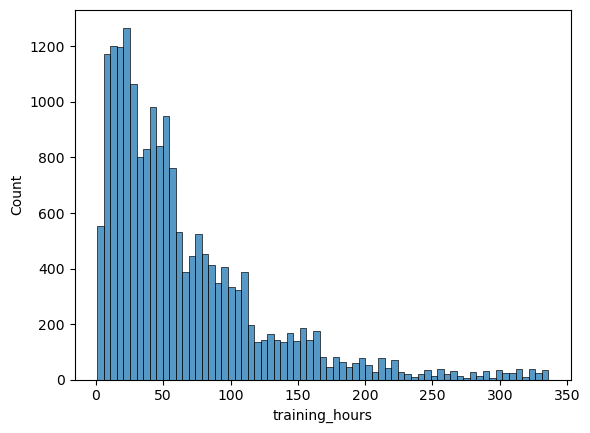

In [461]:
sns.histplot(df["training_hours"]); #display the distribution of training_

In [462]:
#I used Q3 + 1.5 x IQR to determine the upper boundary
#I used Q1 - 1.5 x IQR to determine the lower boundary

#For age upper and lower was: 
THQ1 = df['training_hours'].quantile(0.25)
THQ3 = df['training_hours'].quantile(0.75)

THIQR = THQ3 - THQ1

THUpper = THQ3 + 1.5 * THIQR
THLower = THQ1 - 1.5 * THIQR
print("Training_hours Upper:",THUpper,"\nTraining_hours Lower:",THLower,"\n")

Training_hours Upper: 185.5 
Training_hours Lower: -74.5 



In [463]:
#As the lower boundary is unimportant, I will remove the outliers with the upper cap.
df.loc[df["training_hours"] > 185.5, "training_hours"] = 185.5

<Axes: xlabel='training_hours', ylabel='Count'>

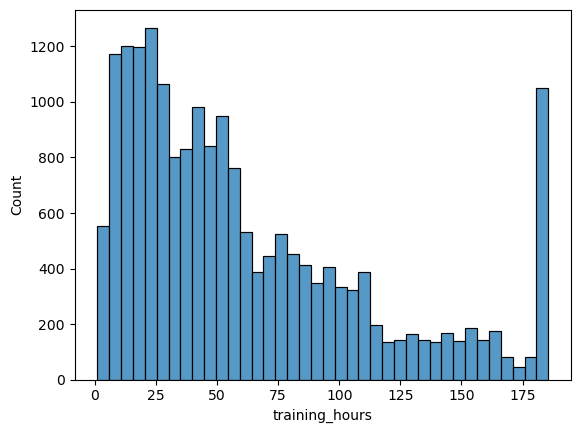

In [464]:
#check distribution 
sns.histplot(df["training_hours"])

In [465]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,62.176793,50.212703,1.000,23.00,47.000,88.00,185.500
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


Data Preprocessing Observations/Summary:
- With those changes there are no other outliers that impact our numeric data 

## Exploratory Data Analysis

In [466]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [467]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [468]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [469]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

In [470]:
#List all the columns and their datatypes
df.dtypes

city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours            float64
target                    float64
dtype: object

#### Categorical Features:
- city
- gender
- relevent_experience
- enrolled_university
- education_level
- major_discipline
- experience
- company_size
- company_type
- last_new_job

##### city

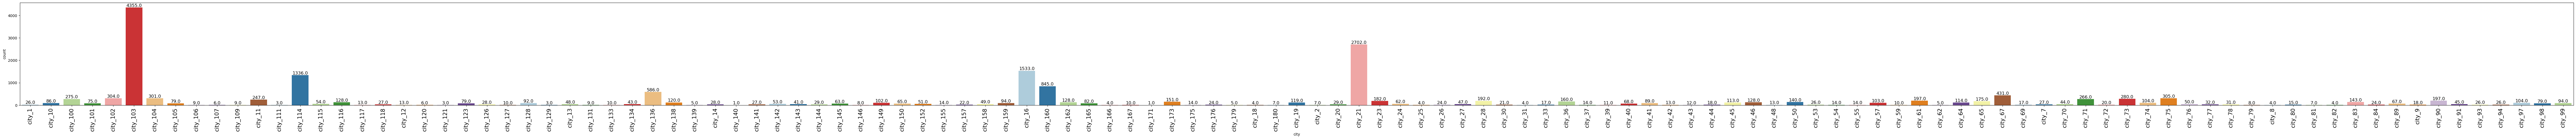

In [471]:
labeled_barplot(df, 'city')

In [472]:
df.city.describe().T

count        19158
unique         123
top       city_103
freq          4355
Name: city, dtype: object

In [473]:
#turn city into a int to make the data better for the model
df['city'] = df['city'].str.replace('city_', '', regex=False).astype(int)

Will come back to in the numeric section.

##### gender

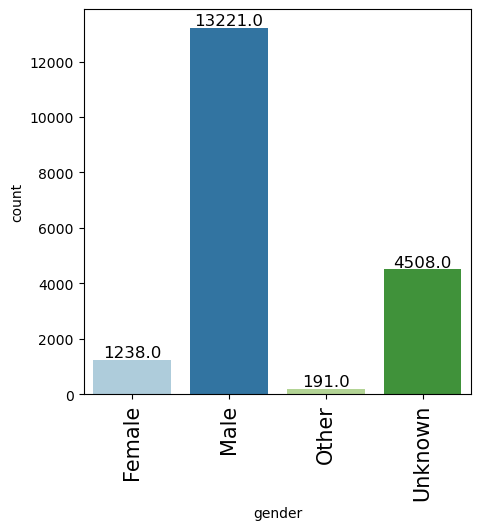

In [474]:
labeled_barplot(df, 'gender')

Observations: 
- This data mostly represents males
- A good portion of our genders are Unknown
- females and others are underrepresented

##### relevent_experience

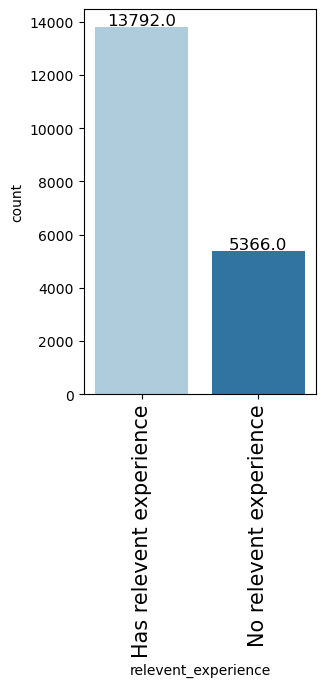

In [475]:
labeled_barplot(df, 'relevent_experience')

Observations: 
- This data mostly represents people who have relevant experience for the job
- We can change the values in feature engineering to make it more efficient 

##### enrolled_university

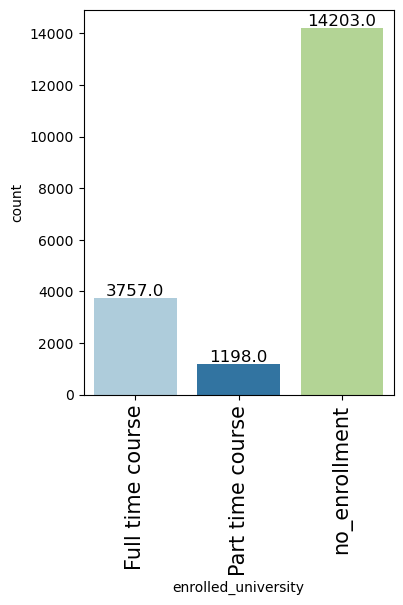

In [476]:
labeled_barplot(df, 'enrolled_university')

Observations: 
- This data mostly represents people who are not enrolled 
- This could also be configured better with feature engineering
- Full and part time courses are underrepresented

##### education_level

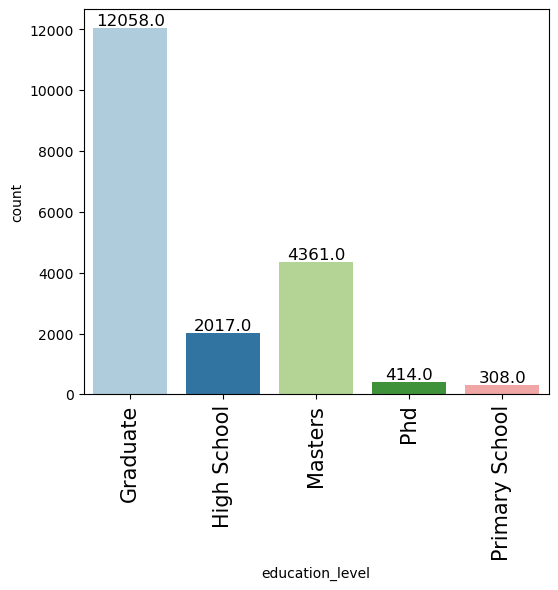

In [477]:
labeled_barplot(df, 'education_level')

Observations: 
- This data mostly represents Graduates 
- The data also represents a good portion of other groups 
- Phd and Primary School have the least

##### major_discipline

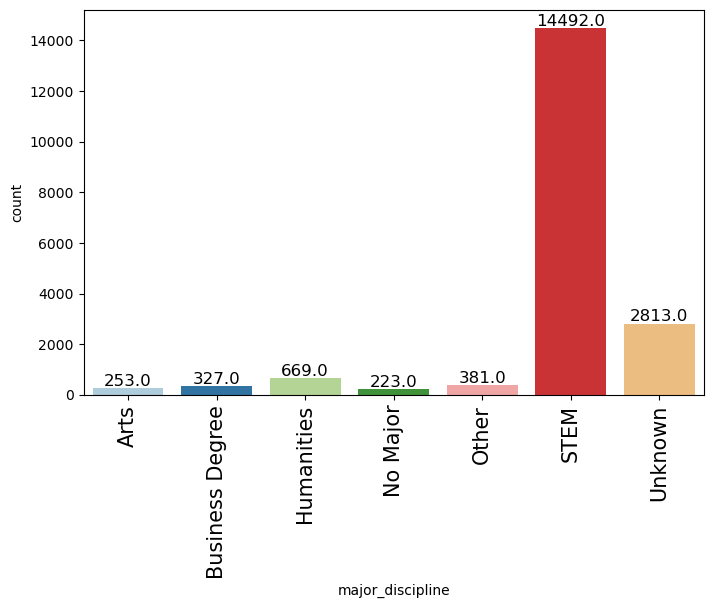

In [478]:
labeled_barplot(df, 'major_discipline')

Observations: 
- This data mostly represents STEM Student 
- A good portion of our majors are Unknown
- There are not many other majors with a lot of representation

##### experience

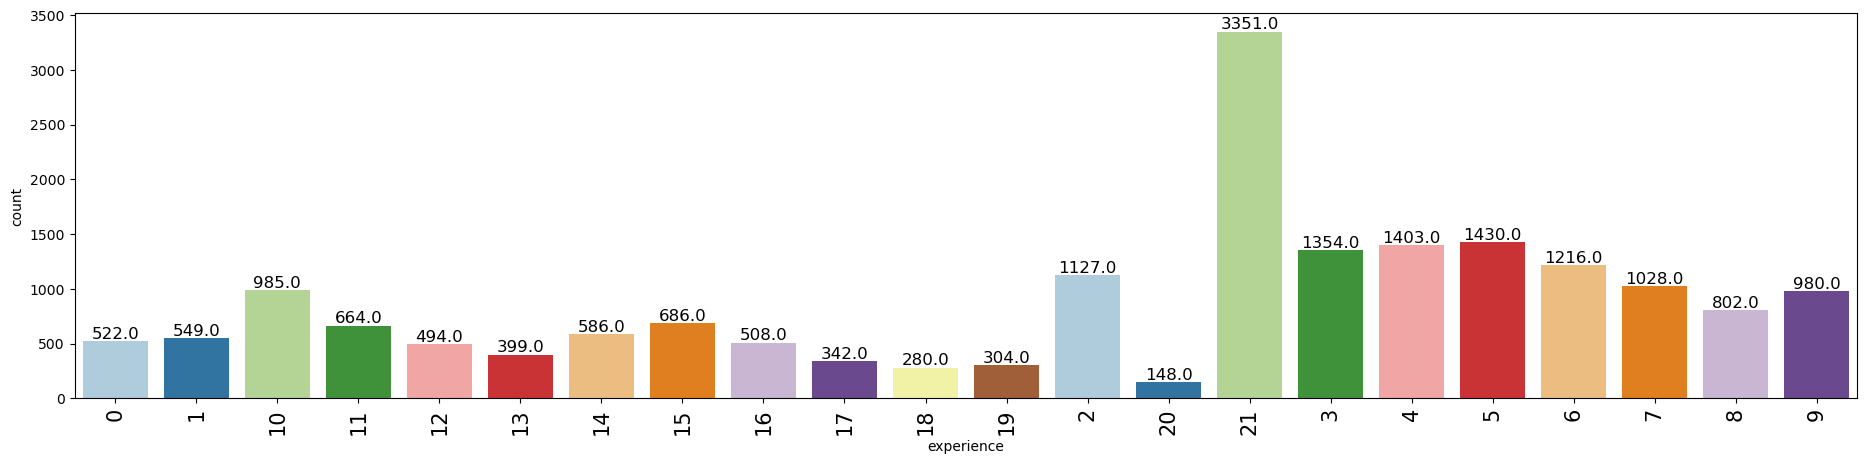

In [479]:
labeled_barplot(df, 'experience')

Observations: 
- A lot of people have over 20 years of experience
- The other years of experience are pretty spread out

##### company_size

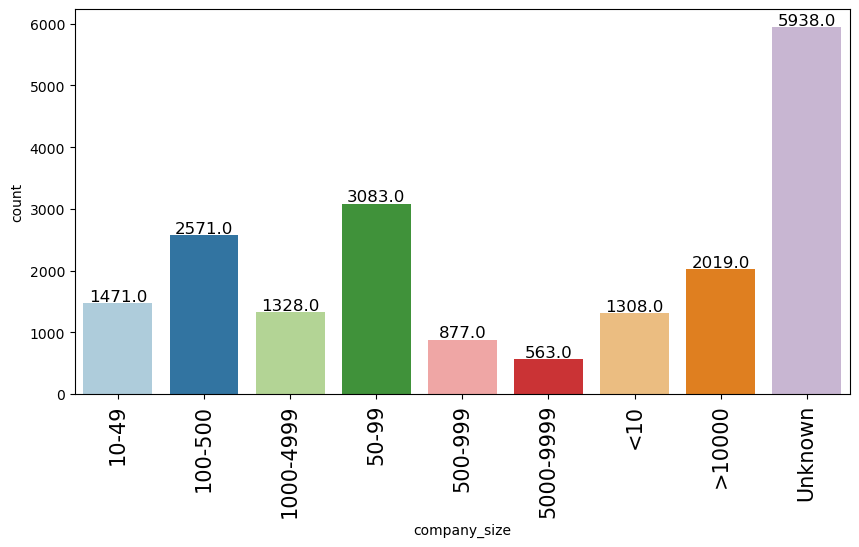

In [480]:
labeled_barplot(df, 'company_size')

Observations: 
- This data mostly represents unknown 
- We should look at the rows with unknown and determine if the column or rows hold value to the model
- Without the Unknowns, the company sizes are pretty spread out

##### company_type

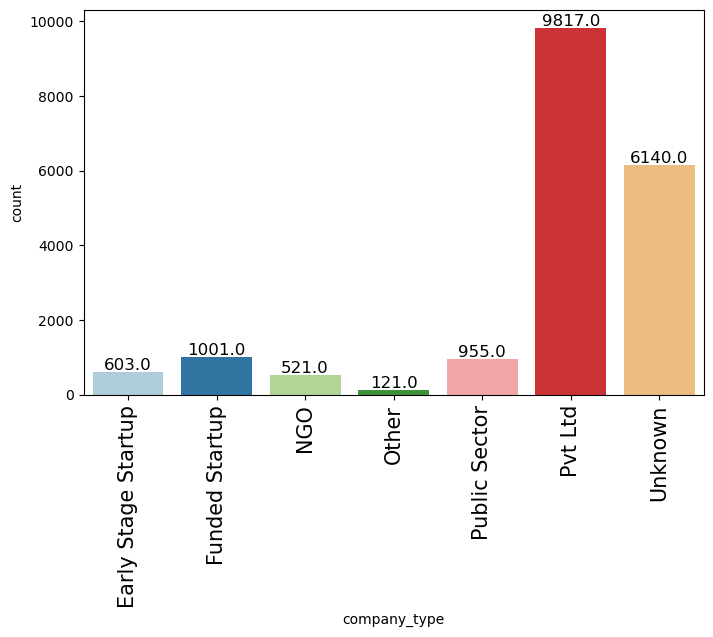

In [481]:
labeled_barplot(df, 'company_type')

Observations: 
- This data mostly represents Pvt Ltd and Unknown 
- The other categories are pretty spread out 

##### last_new_job

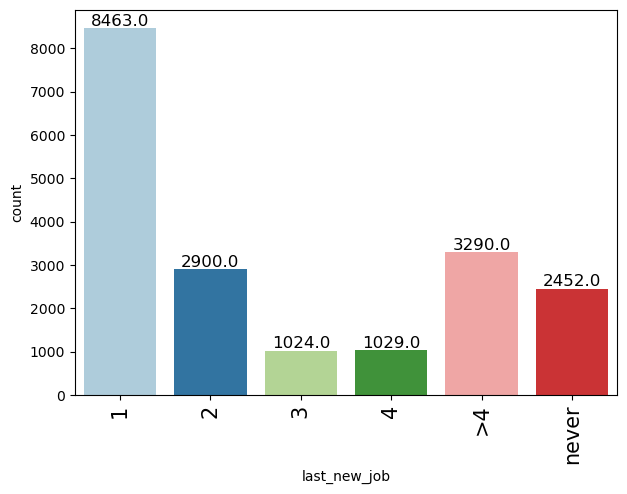

In [482]:
labeled_barplot(df, 'last_new_job')

Observations: 
- This data mostly represents people with 1 year between their last job and their current job 
- A good portion of the data is 2 years, greater than 4 years, and never 

#### Numerical Features:
- city
- city_development_index
- training_hours
- target

In [483]:
df.city.describe()

count    19158.000000
mean        80.128876
std         46.413570
min          1.000000
25%         21.000000
50%        101.000000
75%        104.000000
max        180.000000
Name: city, dtype: float64

In [484]:
df.city.mode()

0    103
Name: city, dtype: int64

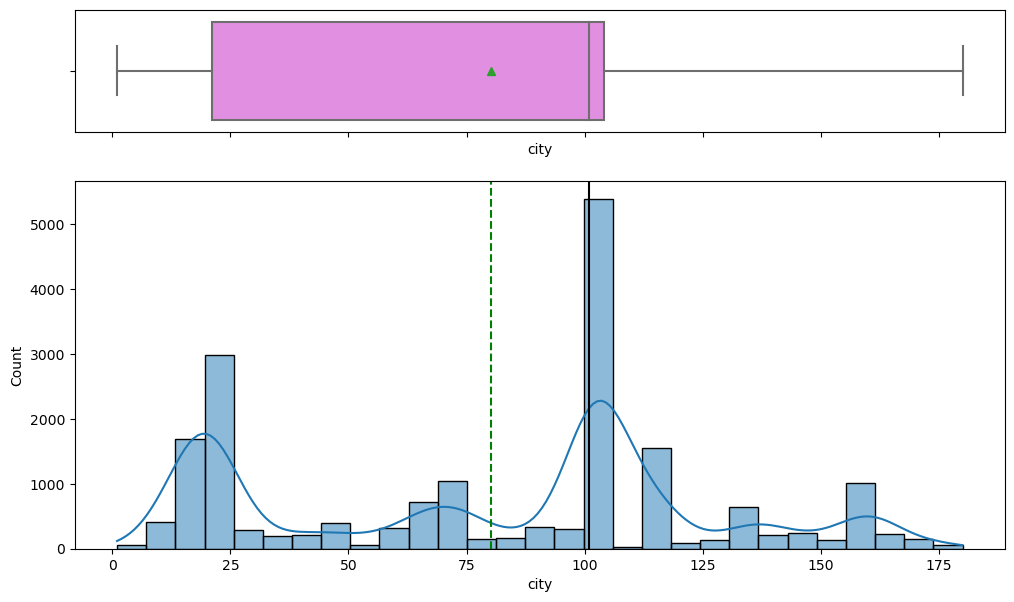

In [485]:
histogram_boxplot(df, 'city',kde=True)

Observations:
- Most people are from city code 103
- The data is pretty spread out, with a few spikes at 25, 100, and 150
- Skewed even
- Mean/Median: 80.1288
- Range: 1-180
- Mode: 103

In [486]:
df.city_development_index.describe()

count    19158.000000
mean         0.828848
std          0.123362
min          0.448000
25%          0.740000
50%          0.903000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

In [487]:
df.city_development_index.mode()

0    0.92
Name: city_development_index, dtype: float64

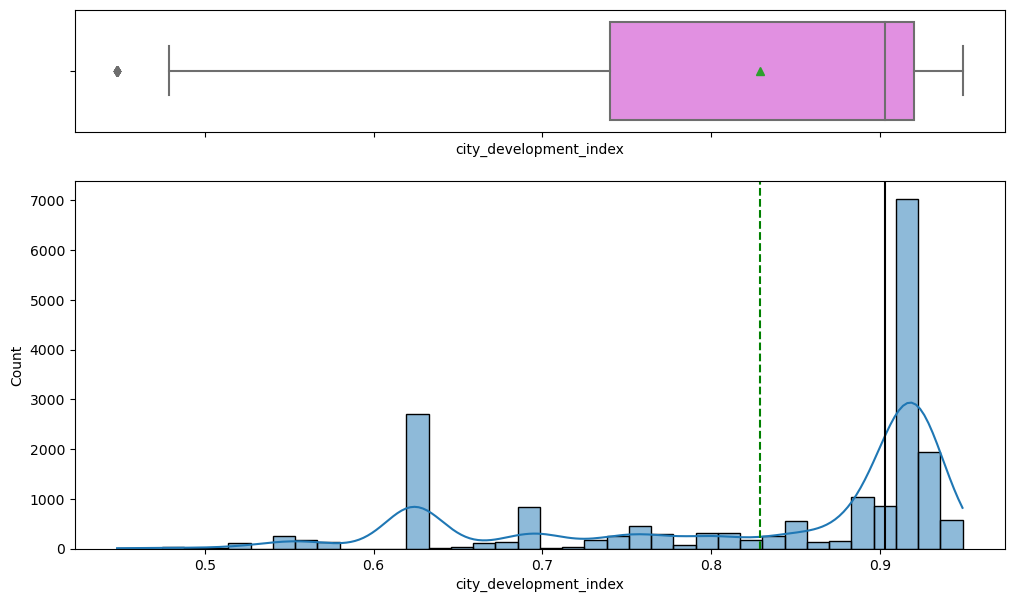

In [488]:
histogram_boxplot(df, 'city_development_index',kde=True)

Observations:
-The data is already scaled
- most of the data is above 0.8 
- Skewed left 
- Mean/Median: 0.8288
- Range: 0-1
- Mode: 0.92

In [489]:
df.training_hours.describe()

count    19158.000000
mean        62.176793
std         50.212703
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        185.500000
Name: training_hours, dtype: float64

In [490]:
df.training_hours.mode()

0    185.5
Name: training_hours, dtype: float64

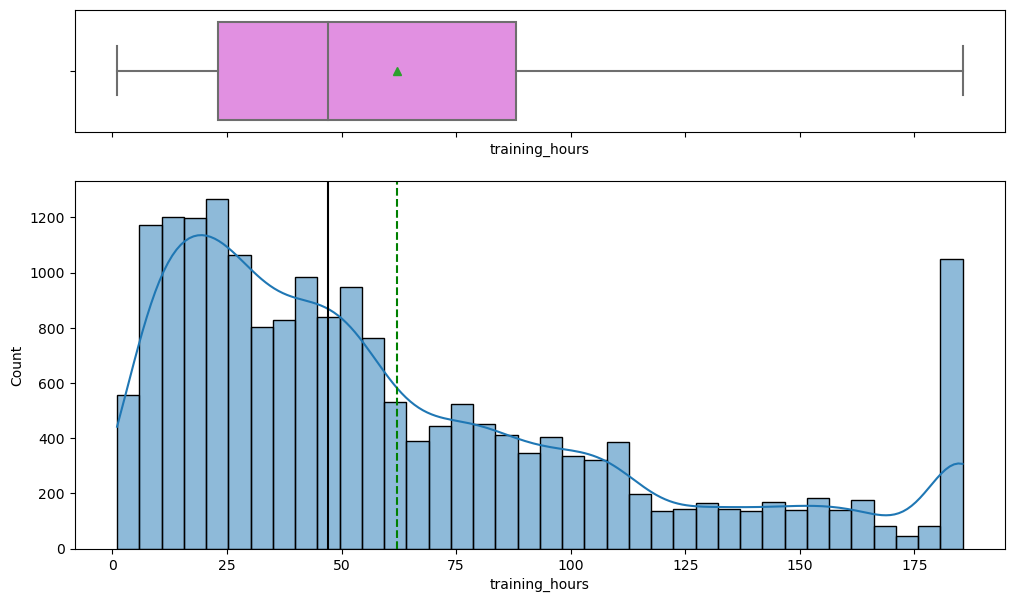

In [491]:
histogram_boxplot(df, 'training_hours',kde=True)

Observations:
- The data is mostly under 125, but with our outliers being replaced to 185.5, the distribution spikes at 185.5
- Skewed right
- Mean/Median: 62.177
- Range: 1-185.5
- Mode: 185.5

In [492]:
df.target.describe()

count    19158.000000
mean         0.249348
std          0.432647
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target, dtype: float64

In [493]:
df.target.mode()

0    0.0
Name: target, dtype: float64

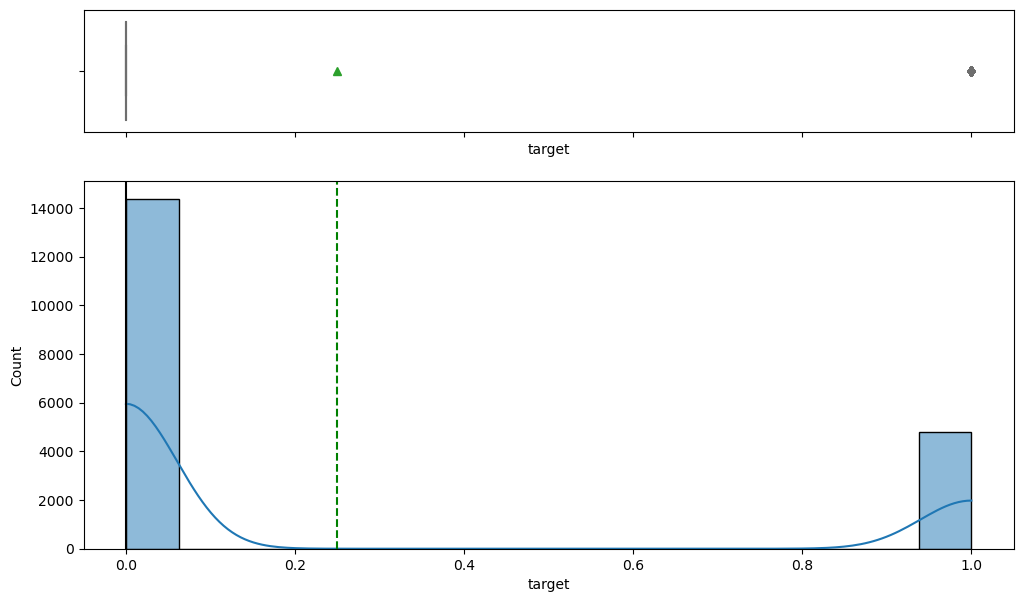

In [494]:
histogram_boxplot(df, 'target',kde=True)

Observations:
- Most of the participants in the data are not looking for a new job position 
- Skewed right
- Mean/Median: 0.249
- Range: 0-1
- Mode: 0

### Multivariate Analysis

#### Feature Correlation Charts

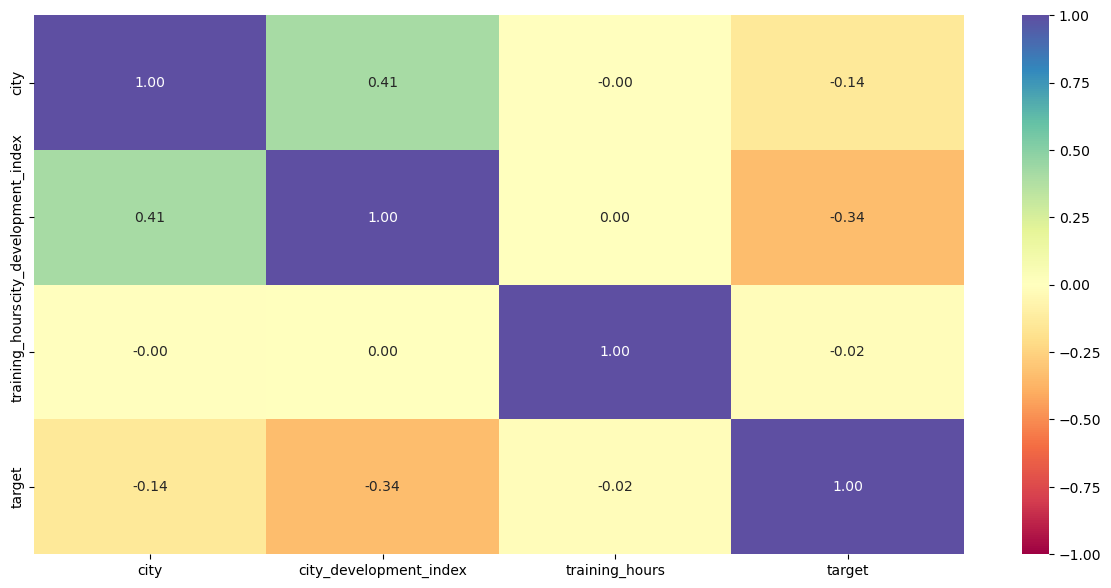

In [495]:
#There are not that many numeric columns but this can give us a good idea of their relationships
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Observations:
- Most of our numeric data does not have much effect on our target.
- I am considering dropping city and training_hours as of now.
- city_development_index seems to have a decent negative correlation with our target, which could be good for our model.
- city and city_development_index have a positive correlation, further leading me to want to drop city.

In [496]:
df = df.drop(['city'], axis=1)

#### Bivariate Analysis - numeric and categorical features

In [497]:
df.groupby("target").city_development_index.mean()

target
0.0    0.853139
1.0    0.755719
Name: city_development_index, dtype: float64

In [498]:
df.groupby("target").training_hours.mean()

target
0.0    62.735067
1.0    60.496127
Name: training_hours, dtype: float64

Observations:
- Both city_development_index and training_hours averages for each option are close to each other.
- Both have a higher average for the non targets than the targets. 

In [499]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
14181,0.556,Male,Has relevent experience,Part time course,Graduate,STEM,7,1000-4999,Pvt Ltd,1,102.0,0.0
13669,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,Unknown,Unknown,2,8.0,0.0
10909,0.920,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,10,>10000,Pvt Ltd,1,28.0,0.0
10711,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,5000-9999,Unknown,1,34.0,0.0
9303,0.910,Male,No relevent experience,Full time course,Graduate,STEM,2,>10000,Pvt Ltd,1,48.0,0.0
1662,0.926,Male,No relevent experience,Full time course,High School,Unknown,3,5000-9999,Pvt Ltd,1,63.0,1.0
14244,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,15,Unknown,Unknown,>4,65.0,1.0
6940,0.698,Male,Has relevent experience,no_enrollment,Masters,STEM,3,Unknown,Unknown,1,61.0,0.0
8231,0.926,Unknown,Has relevent experience,Part time course,Graduate,STEM,10,10-49,Early Stage Startup,1,4.0,0.0
18136,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,4,100-500,NGO,1,26.0,0.0


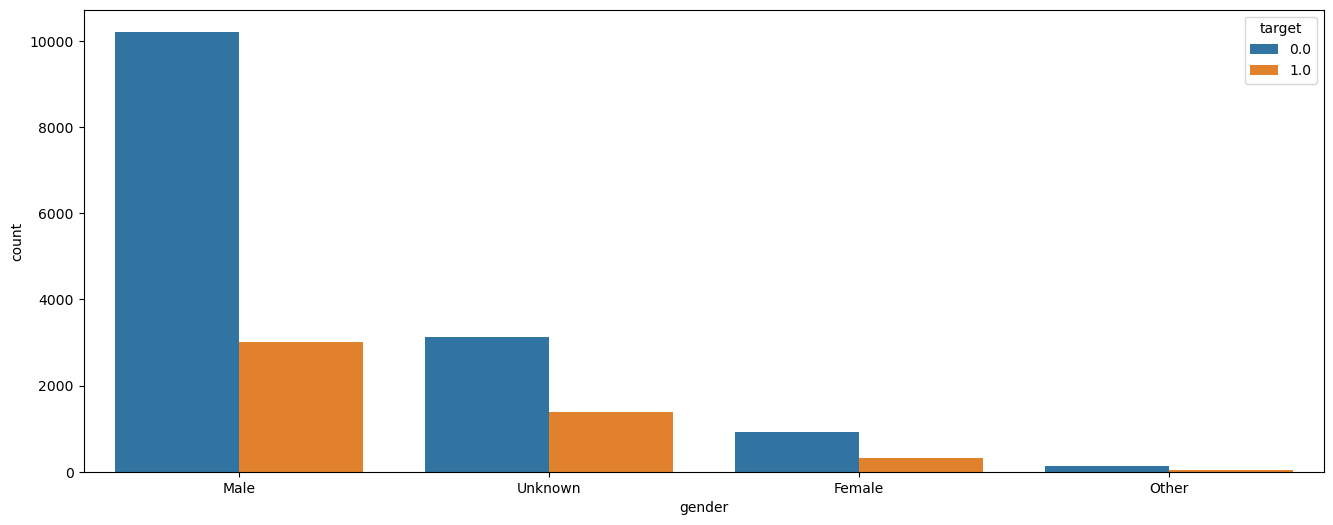

In [500]:
plt.figure(figsize=(16, 6))  # Adjust width and height
sns.countplot(data=df,hue='target', x='gender');

In [501]:
pd.crosstab(df['target'],df['gender'])

gender,Female,Male,Other,Unknown
target,,,,
0.0,912,10209,141,3119
1.0,326,3012,50,1389


Observations:
- every gender has about a 1:3 ratio to the target, with most of them being from the 0

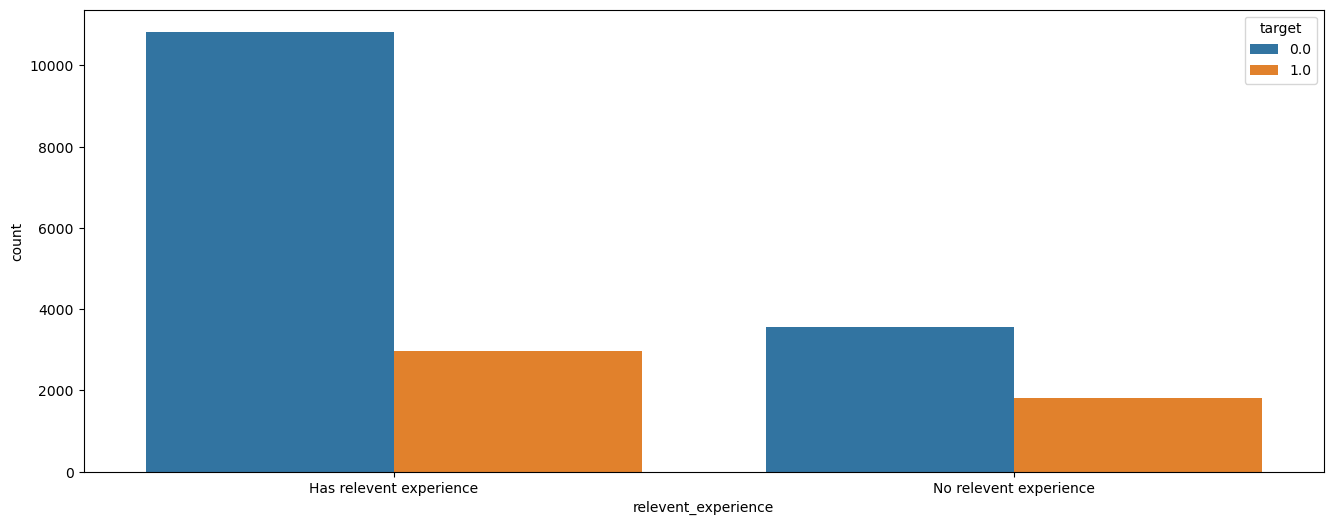

In [502]:
plt.figure(figsize=(16, 6))
sns.countplot(data=df,hue='target', x='relevent_experience');

In [503]:
pd.crosstab(df['target'],df['relevent_experience'])

relevent_experience,Has relevent experience,No relevent experience
target,,
0.0,10831,3550
1.0,2961,1816


Observations:
- The majority of people who have relevant experience are not looking for a job change
- People with no relevant experience are half as likely to be looking for a job change as not looking for a job change.
- relevant experience has a large sample

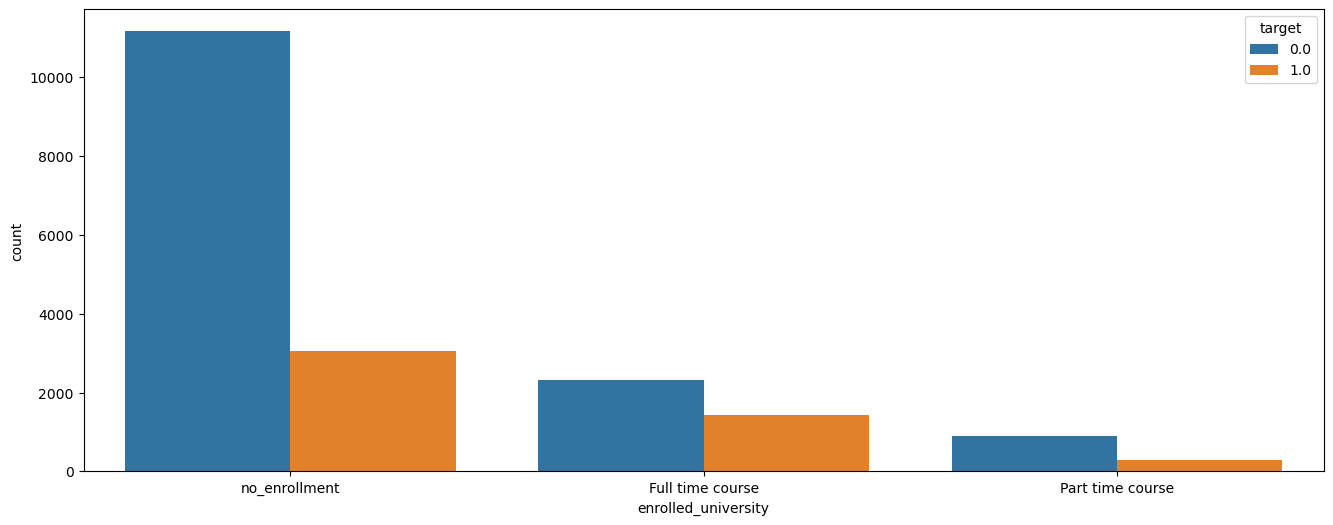

In [504]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='enrolled_university');

In [505]:
pd.crosstab(df['target'],df['enrolled_university'])

enrolled_university,Full time course,Part time course,no_enrollment
target,,,
0.0,2326,896,11159
1.0,1431,302,3044


Observations:
- no_enrollment has the highest sample
- almost 4 times the number of people with no enrollment are not looking for a job change
- around 1/3 of full time univeristy students are looking for a job change
- part time course has the smallest sample

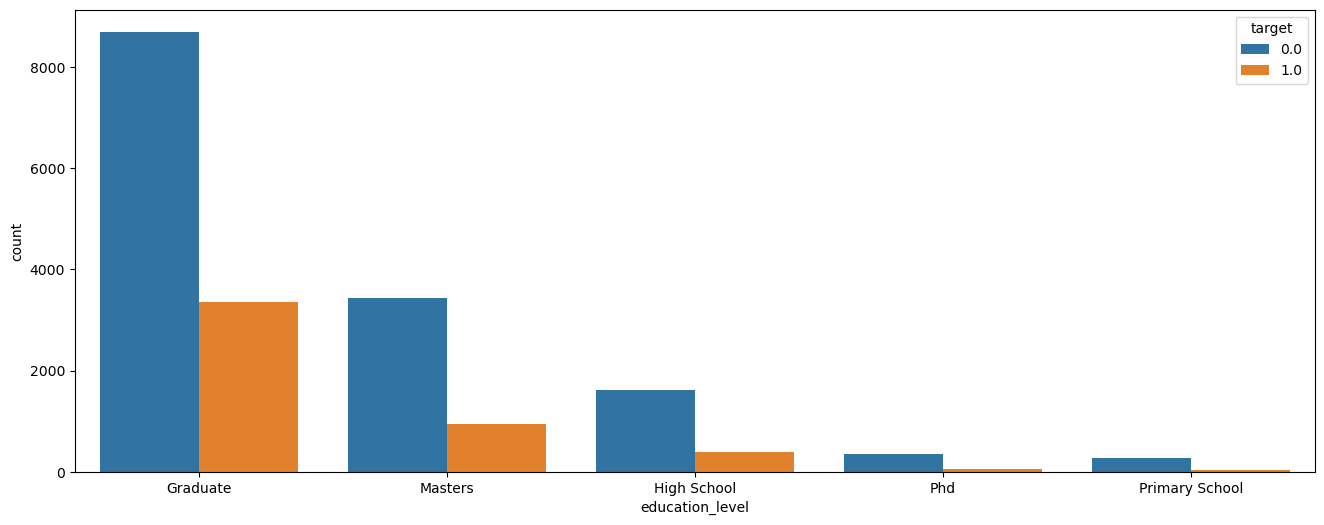

In [506]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='education_level');

In [507]:
pd.crosstab(df['target'],df['education_level'])

education_level,Graduate,High School,Masters,Phd,Primary School
target,,,,,
0.0,8709,1623,3426,356,267
1.0,3349,394,935,58,41


Observations:
- Graduates are the most represented in this data
- Most of every level is not looking for a job change 

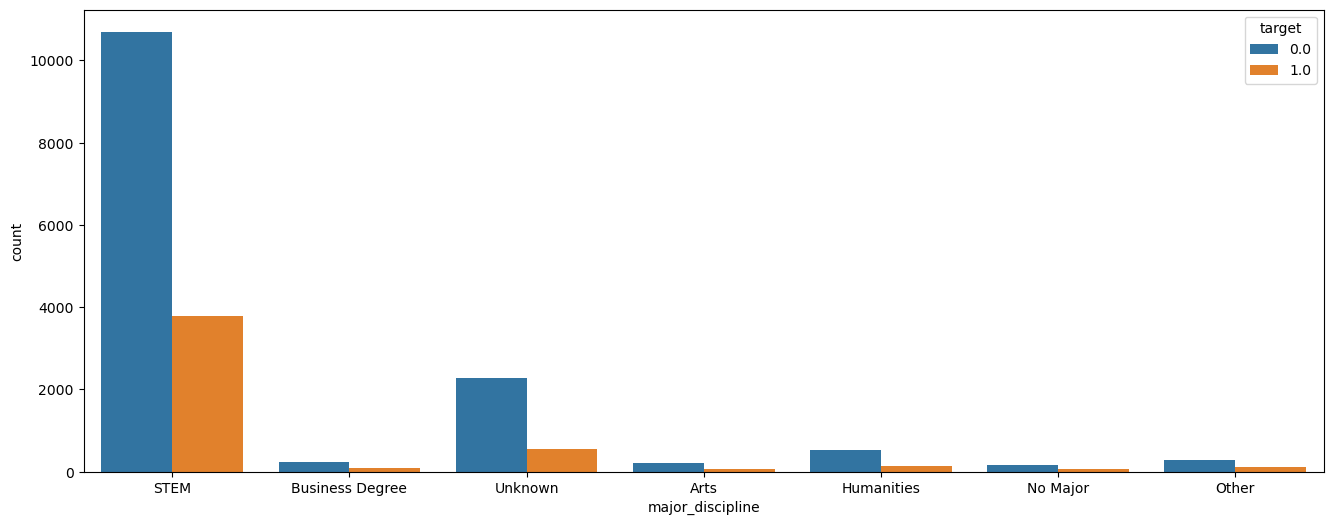

In [508]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='major_discipline');

In [509]:
pd.crosstab(df['target'],df['major_discipline'])

major_discipline,Arts,Business Degree,Humanities,No Major,Other,STEM,Unknown
target,,,,,,,
0.0,200,241,528,168,279,10701,2264
1.0,53,86,141,55,102,3791,549


Observations:
- Most of the people in this data set are STEM or Unknown
- people in STEM are 3x more likely not be looking for a job change
- Other majors are severly under represented

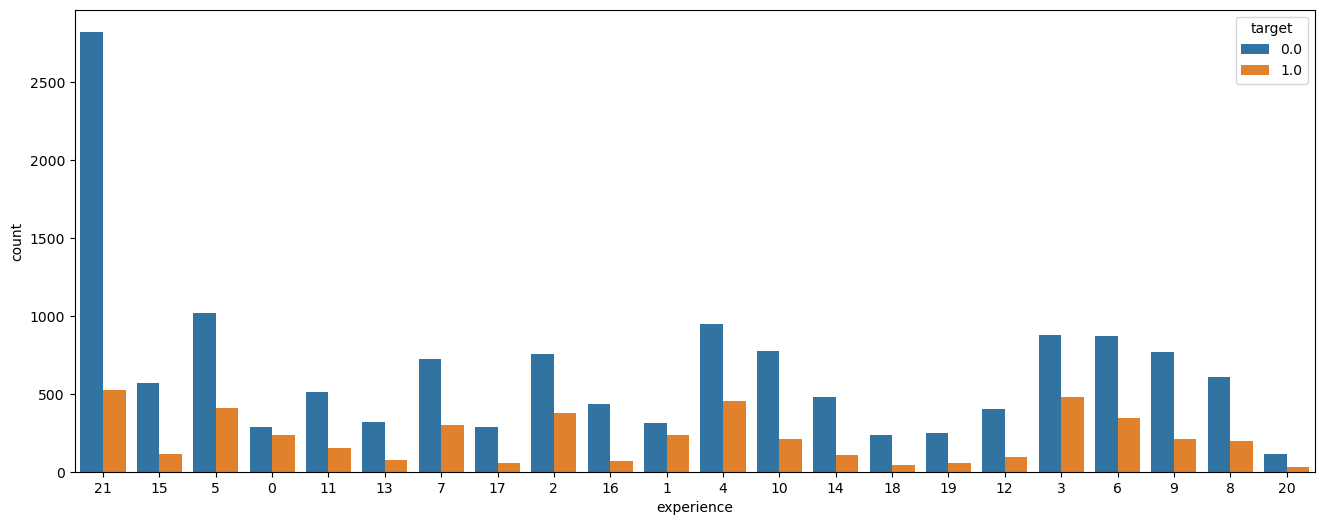

In [510]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='experience');

In [511]:
pd.crosstab(df['target'],df['experience'])

experience,0,1,10,11,12,13,14,15,16,17,...,2,20,21,3,4,5,6,7,8,9
target,,,,,,,,,,,,,,,,,,,,,
0.0,285,316,778,513,402,322,479,572,436,285,...,753,115,2825,876,946,1018,873,725,607,767
1.0,237,233,207,151,92,77,107,114,72,57,...,374,33,526,478,457,412,343,303,195,213


Observations:
- We could probably get more value from this column after binning
- people with more than 20 years of work experience are less likely to look for a job change
- most people in the data have over 20 years of experience

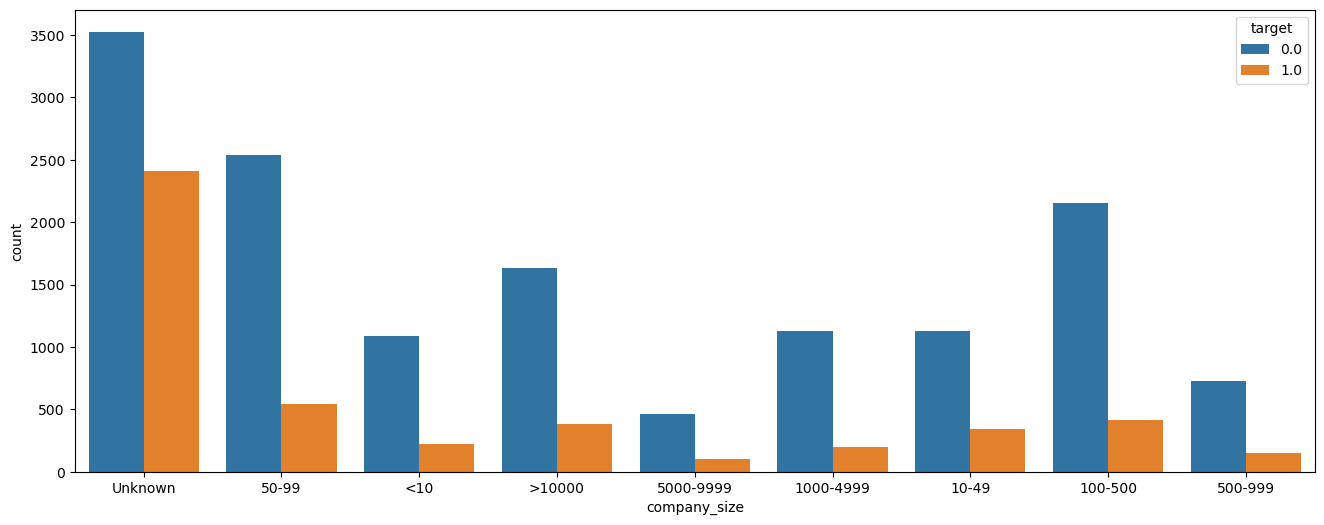

In [512]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='company_size');

In [513]:
pd.crosstab(df['target'],df['company_size'])

company_size,10-49,100-500,1000-4999,50-99,500-999,5000-9999,<10,>10000,Unknown
target,,,,,,,,,
0.0,1127,2156,1128,2538,725,461,1084,1634,3528
1.0,344,415,200,545,152,102,224,385,2410


Observations:
- Majority of the data is unknown, might delete column or rows 
- without the unknown, the data is pretty spread out, with most of the participants being from 50-99

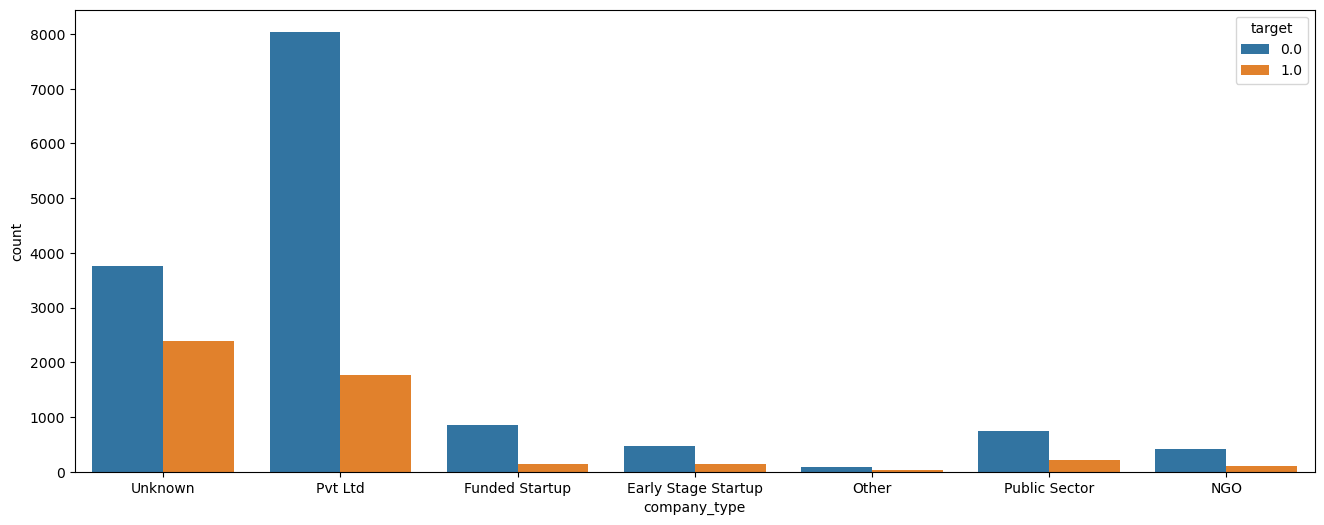

In [514]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='company_type');

In [515]:
pd.crosstab(df['target'],df['company_type'])

company_type,Early Stage Startup,Funded Startup,NGO,Other,Public Sector,Pvt Ltd,Unknown
target,,,,,,,
0.0,461,861,424,92,745,8042,3756
1.0,142,140,97,29,210,1775,2384


Observations:
- Most of the companies are Pvt Ltd or unknown
- Need to look at unknown columns to see if they're needed
- Most Pvt Ltd's are not looking to change their job

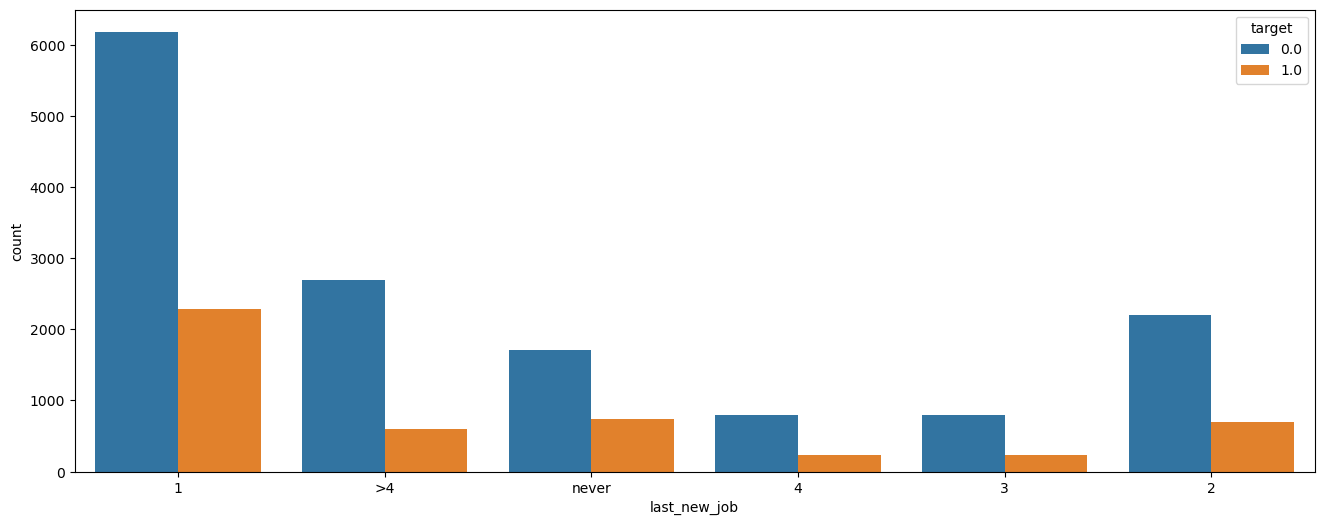

In [516]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='last_new_job');

In [517]:
pd.crosstab(df['target'],df['last_new_job'])

last_new_job,1,2,3,4,>4,never
target,,,,,,
0.0,6184,2200,793,801,2690,1713
1.0,2279,700,231,228,600,739


Observations:
- Most of the participants have a year between their current job and their last job 
- Most people with a year from their last job are not looking for a job change
- People who have never had a job, around half are looking for a job change

In [518]:
df[df["company_type"] == 'Unknown']

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21,Unknown,Unknown,1,36.0,1.0
2,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83.0,0.0
5,0.764,Unknown,Has relevent experience,Part time course,Graduate,STEM,11,Unknown,Unknown,1,24.0,1.0
10,0.624,Unknown,No relevent experience,Full time course,High School,Unknown,2,Unknown,Unknown,never,32.0,1.0
13,0.624,Male,No relevent experience,no_enrollment,Graduate,Unknown,2,Unknown,Unknown,never,24.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19144,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,4,Unknown,Unknown,never,48.0,1.0
19151,0.689,Male,No relevent experience,Full time course,Graduate,Unknown,2,Unknown,Unknown,1,60.0,0.0
19153,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,Unknown,Unknown,1,42.0,1.0
19154,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,Unknown,Unknown,4,52.0,1.0


In [519]:
df[df["company_type"] == "Unknown"]["company_size"].value_counts()

company_size
Unknown      5360
50-99         222
100-500       152
10-49         105
>10000         77
<10            65
500-999        64
1000-4999      59
5000-9999      36
Name: count, dtype: int64

In [520]:
df[df["company_size"] == 'Unknown']

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21,Unknown,Unknown,1,36.0,1.0
2,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83.0,0.0
3,0.789,Unknown,No relevent experience,no_enrollment,Graduate,Business Degree,0,Unknown,Pvt Ltd,never,52.0,1.0
5,0.764,Unknown,Has relevent experience,Part time course,Graduate,STEM,11,Unknown,Unknown,1,24.0,1.0
10,0.624,Unknown,No relevent experience,Full time course,High School,Unknown,2,Unknown,Unknown,never,32.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19145,0.725,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Pvt Ltd,never,185.5,0.0
19151,0.689,Male,No relevent experience,Full time course,Graduate,Unknown,2,Unknown,Unknown,1,60.0,0.0
19153,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,Unknown,Unknown,1,42.0,1.0
19154,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,Unknown,Unknown,4,52.0,1.0


In [521]:
#create a copy of data
dfnew = df.copy()

In [522]:
dfnew = dfnew[dfnew['company_size'] != 'Unknown']

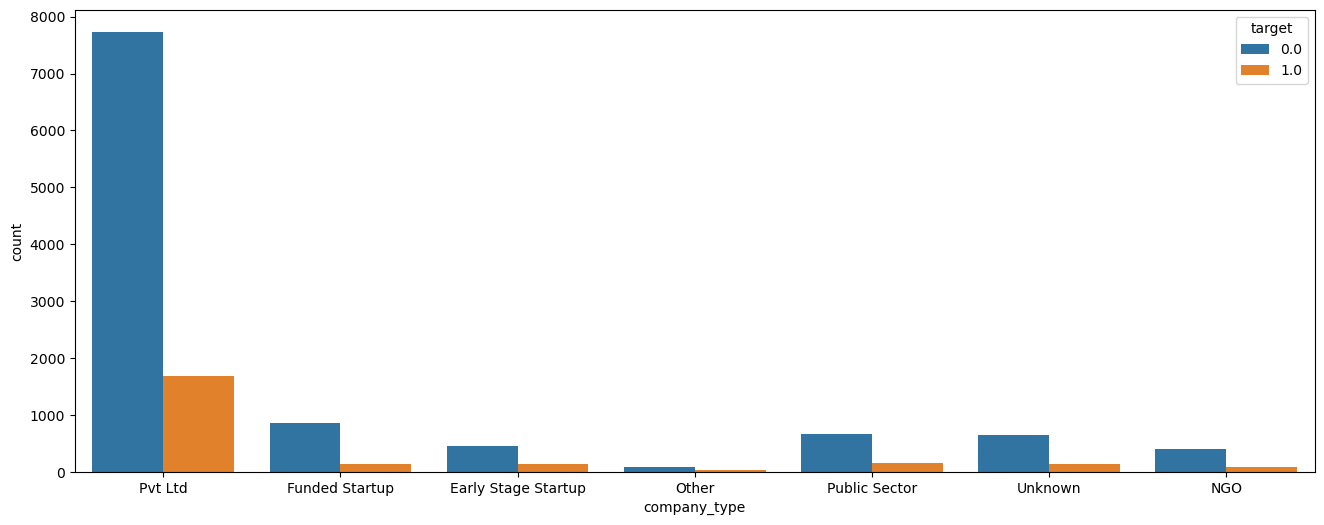

In [523]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=dfnew,hue='target', x='company_type');

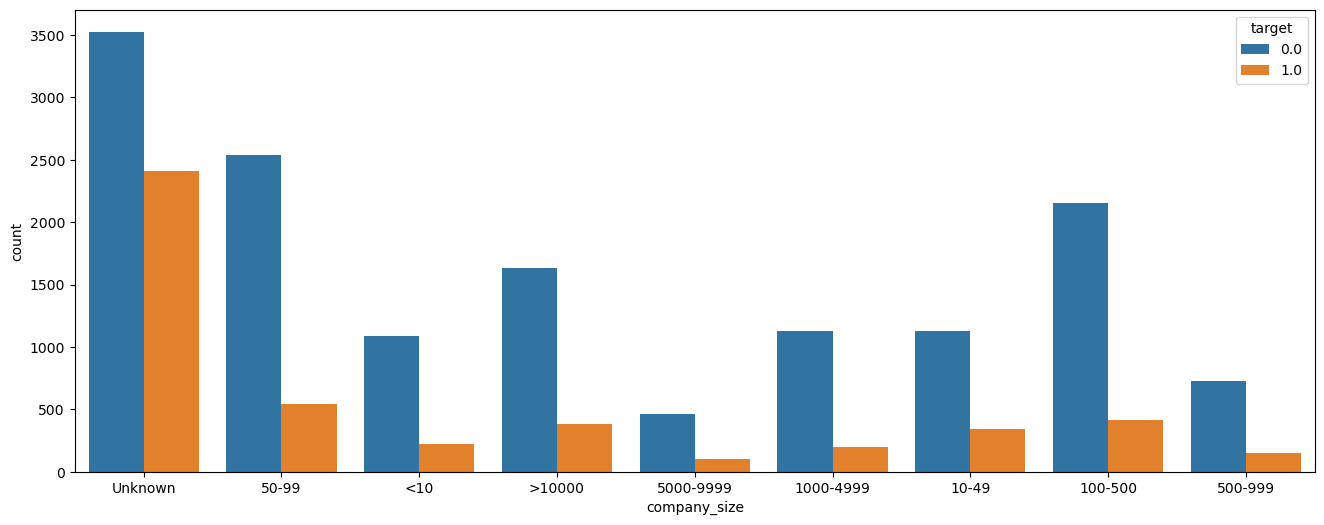

In [524]:
plt.figure(figsize=(16, 6))  
sns.countplot(data=df,hue='target', x='company_size');

Observations:
- After removing the rows in company size that have unknown values we can see a noticeable difference in both of our graphs
- I will see how it affected the rest of the data by re running the code above with the new data frame, and determine if the change was right. 

In [525]:
#after reviewing I am going to change it to the new data frame
df = dfnew 

### EDA Observations/Conclusions

Dropping the unknown values seems to have helped the model a lot. Additionally, it looks like all of the categorical features have at most 1/3 of a chance to be looking for a job change. With the numeric columns, the only column that seems to be of value to the target is city_development_index. A lot of the columns have a mode that stands out more than the other ones. Every categorical column seems to have value towards the target. 

## Feature Engineering

### Consider dropping features

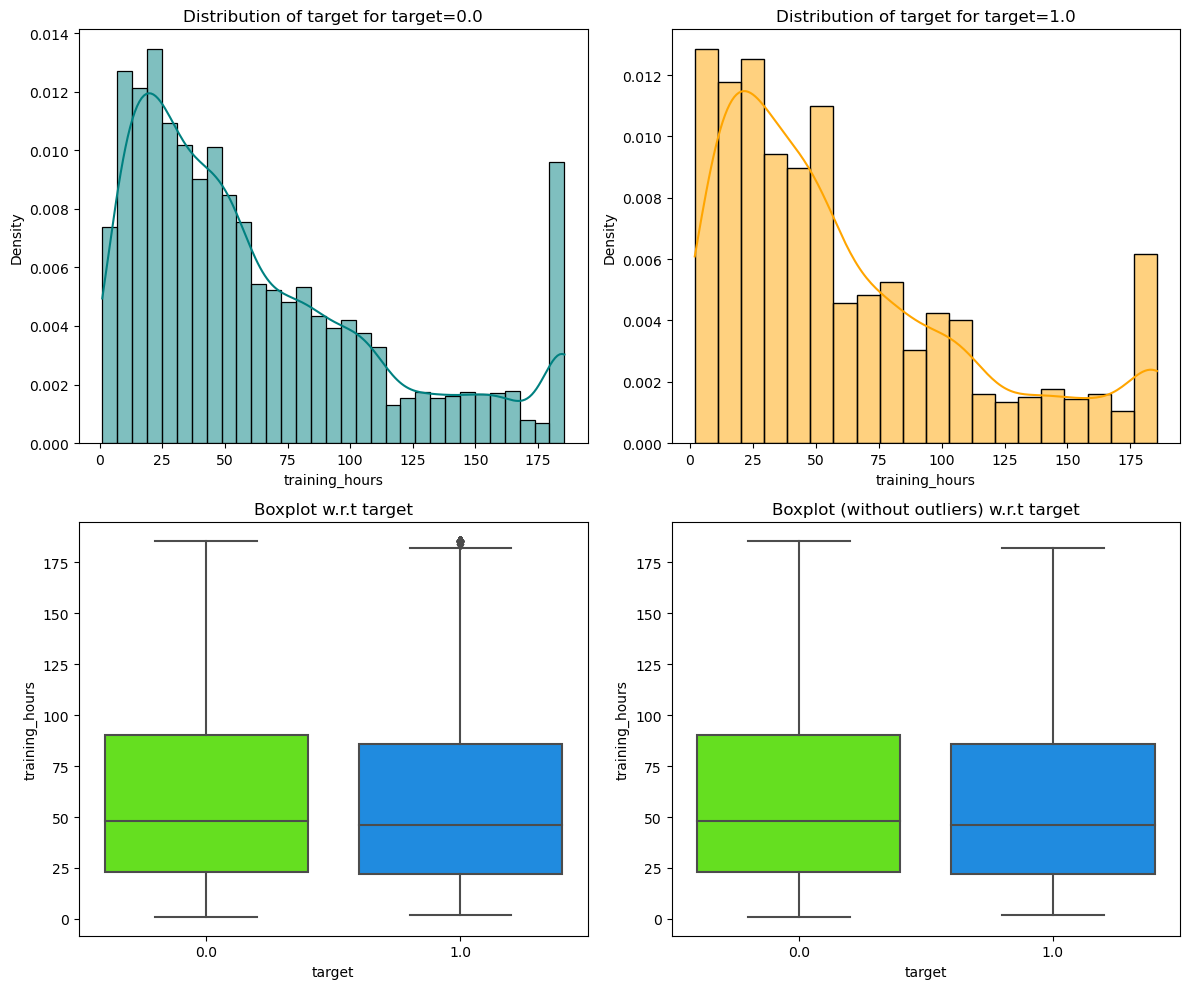

In [526]:
distribution_plot_wrt_target(data=df, predictor='training_hours', target='target') 

Observations:
- The graphs are nearly identical, indicating that they do not predict the target variable in any way
- Because of this, I will drop it 

In [527]:
df = df.drop(['training_hours'], axis=1)

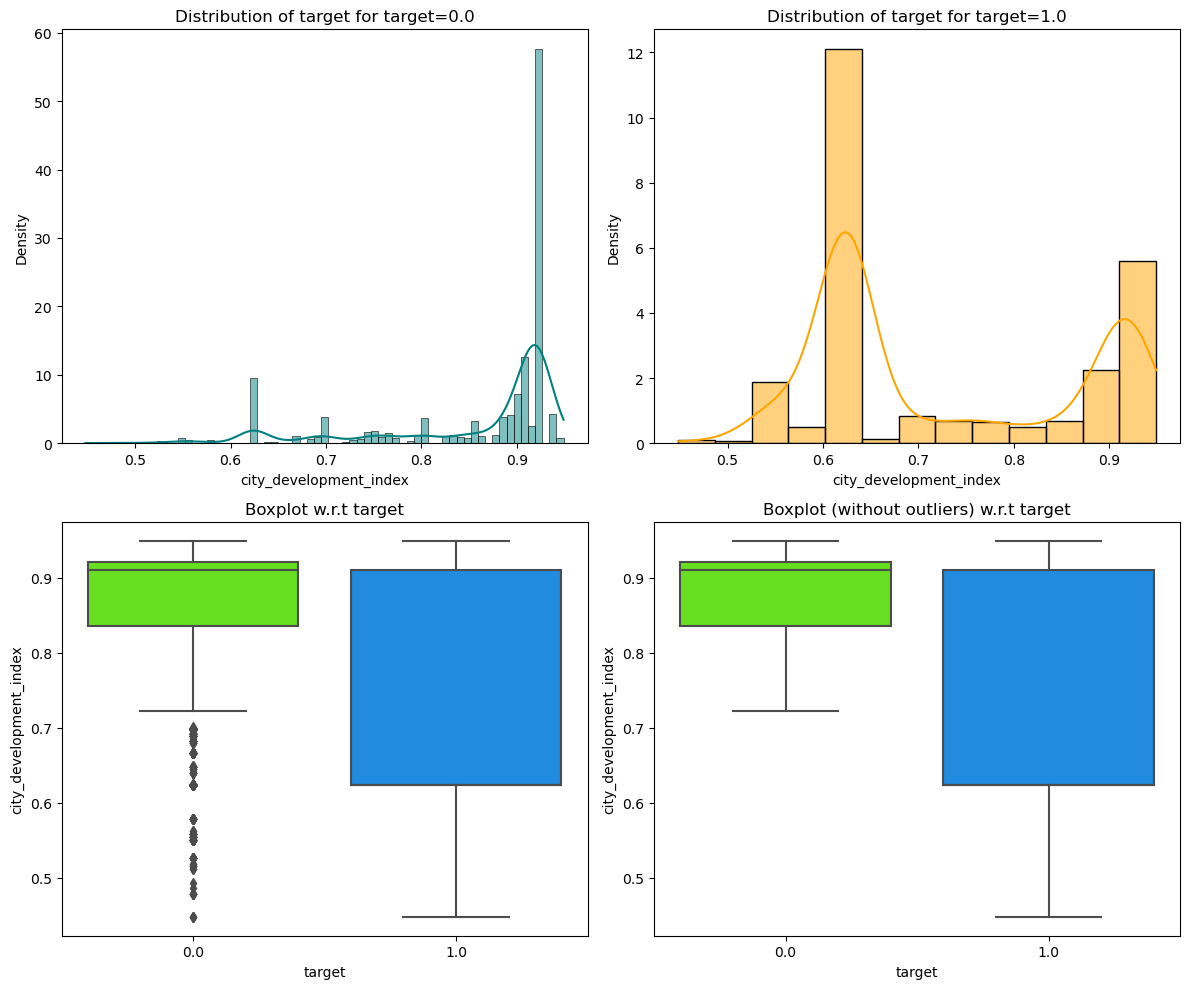

In [528]:
distribution_plot_wrt_target(data=df, predictor='city_development_index', target='target') 

Observations: 
- This seems to hold value to our model so I will keep it 

In [529]:
df.sample(15)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,target
16326,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,13,100-500,Pvt Ltd,>4,0.0
746,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,>10000,Pvt Ltd,>4,0.0
5532,0.624,Female,Has relevent experience,no_enrollment,Graduate,STEM,8,5000-9999,Pvt Ltd,2,0.0
17552,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21,1000-4999,Pvt Ltd,>4,0.0
17365,0.780,Male,No relevent experience,no_enrollment,Graduate,STEM,16,50-99,Pvt Ltd,>4,1.0
17455,0.624,Male,Has relevent experience,Full time course,Graduate,STEM,6,50-99,Pvt Ltd,3,0.0
10502,0.920,Male,No relevent experience,Full time course,Graduate,STEM,10,10-49,Pvt Ltd,3,0.0
6552,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,4,5000-9999,Unknown,1,1.0
208,0.920,Male,Has relevent experience,no_enrollment,Masters,Other,21,100-500,Pvt Ltd,>4,0.0
8677,0.843,Male,Has relevent experience,no_enrollment,Graduate,STEM,15,100-500,Pvt Ltd,>4,0.0


target                     0.0   1.0    All
relevent_experience                        
All                      10853  2367  13220
Has relevent experience   9278  1933  11211
No relevent experience    1575   434   2009
------------------------------------------------------------------------------------------------------------------------


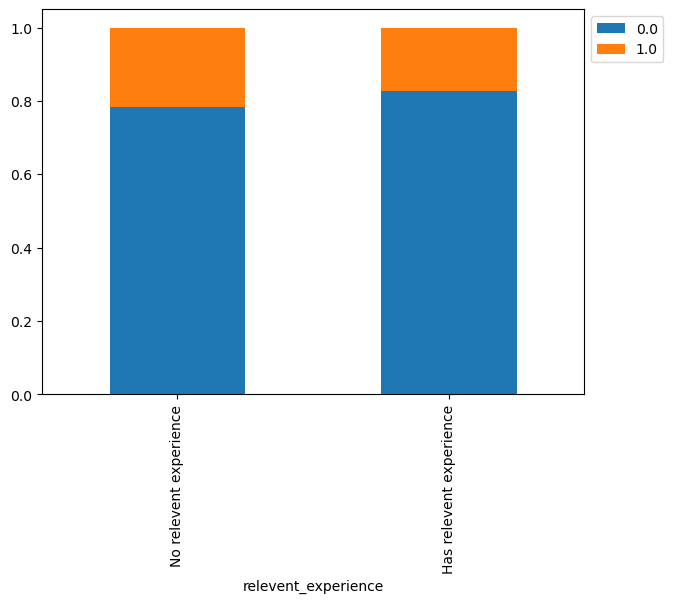

In [530]:
stacked_barplot(data=df, predictor='relevent_experience', target='target')

target     0.0   1.0    All
gender                     
All      10853  2367  13220
Male      7810  1513   9323
Unknown   2190   693   2883
Female     757   145    902
Other       96    16    112
------------------------------------------------------------------------------------------------------------------------


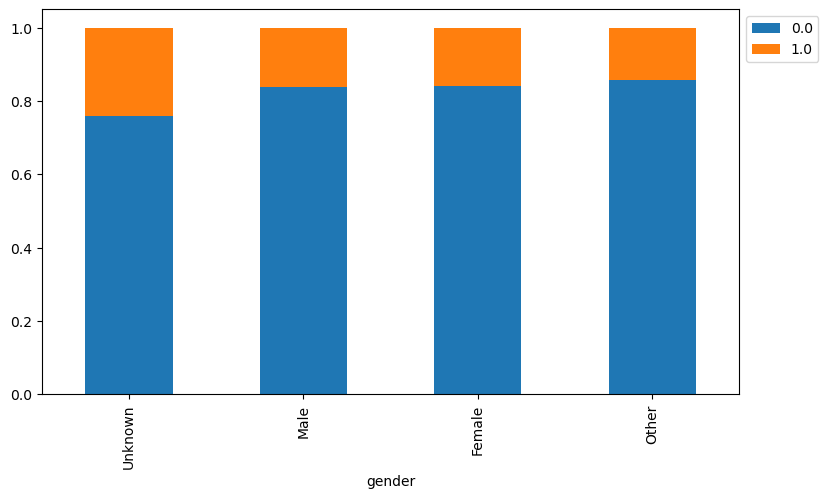

In [531]:
stacked_barplot(data=df, predictor='gender', target='target')

target                 0.0   1.0    All
enrolled_university                    
All                  10853  2367  13220
no_enrollment         8898  1761  10659
Full time course      1218   460   1678
Part time course       737   146    883
------------------------------------------------------------------------------------------------------------------------


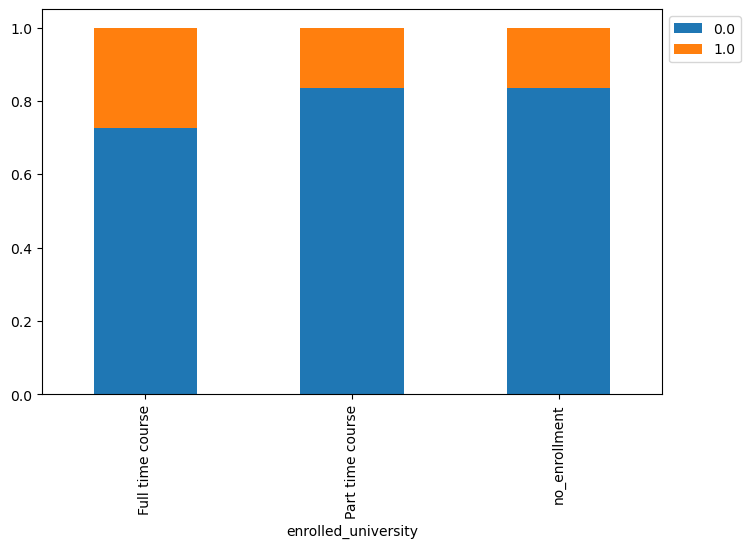

In [532]:
stacked_barplot(data=df, predictor='enrolled_university', target='target')

target             0.0   1.0    All
education_level                    
All              10853  2367  13220
Graduate          6916  1667   8583
Masters           2834   561   3395
High School        769    85    854
Phd                281    43    324
Primary School      53    11     64
------------------------------------------------------------------------------------------------------------------------


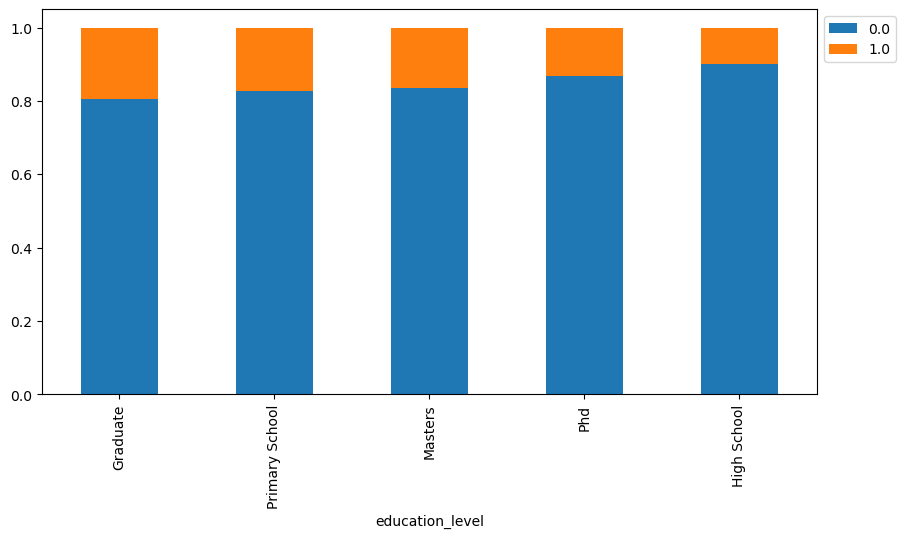

In [533]:
stacked_barplot(data=df, predictor='education_level', target='target')

target              0.0   1.0    All
major_discipline                    
All               10853  2367  13220
STEM               8783  2079  10862
Unknown             955   133   1088
Humanities          416    55    471
Other               216    37    253
Business Degree     190    27    217
No Major            130    19    149
Arts                163    17    180
------------------------------------------------------------------------------------------------------------------------


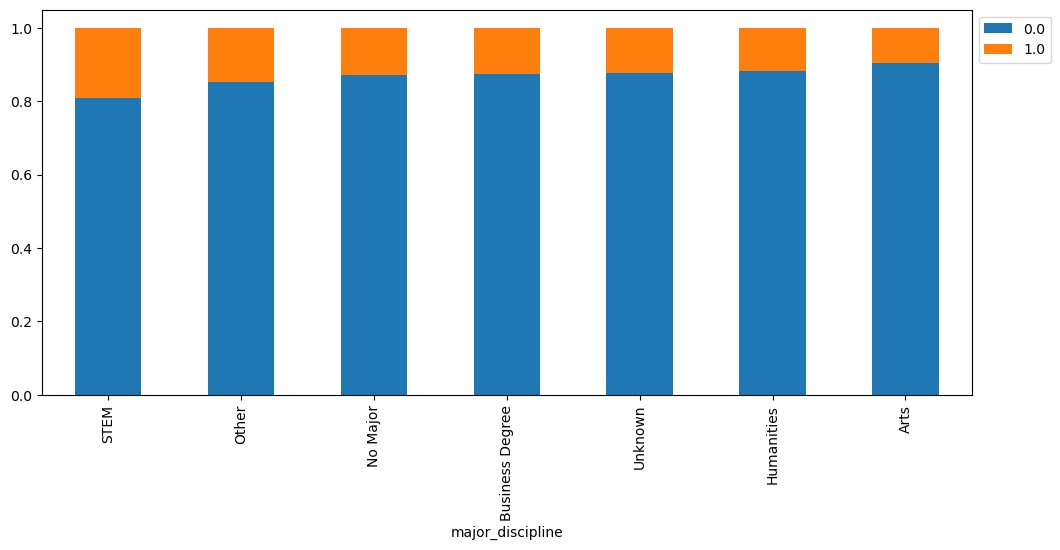

In [534]:
stacked_barplot(data=df, predictor='major_discipline', target='target')

target        0.0   1.0    All
experience                    
All         10853  2367  13220
3             527   228    755
5             727   220    947
4             633   207    840
6             672   195    867
21           2218   193   2411
7             560   157    717
2             441   138    579
9             615   128    743
10            651   126    777
8             490   110    600
1             162   106    268
0             129   102    231
11            430    80    510
15            487    69    556
14            409    65    474
12            338    58    396
13            272    48    320
16            363    42    405
17            230    35    265
19            207    29    236
18            196    20    216
20             96    11    107
------------------------------------------------------------------------------------------------------------------------


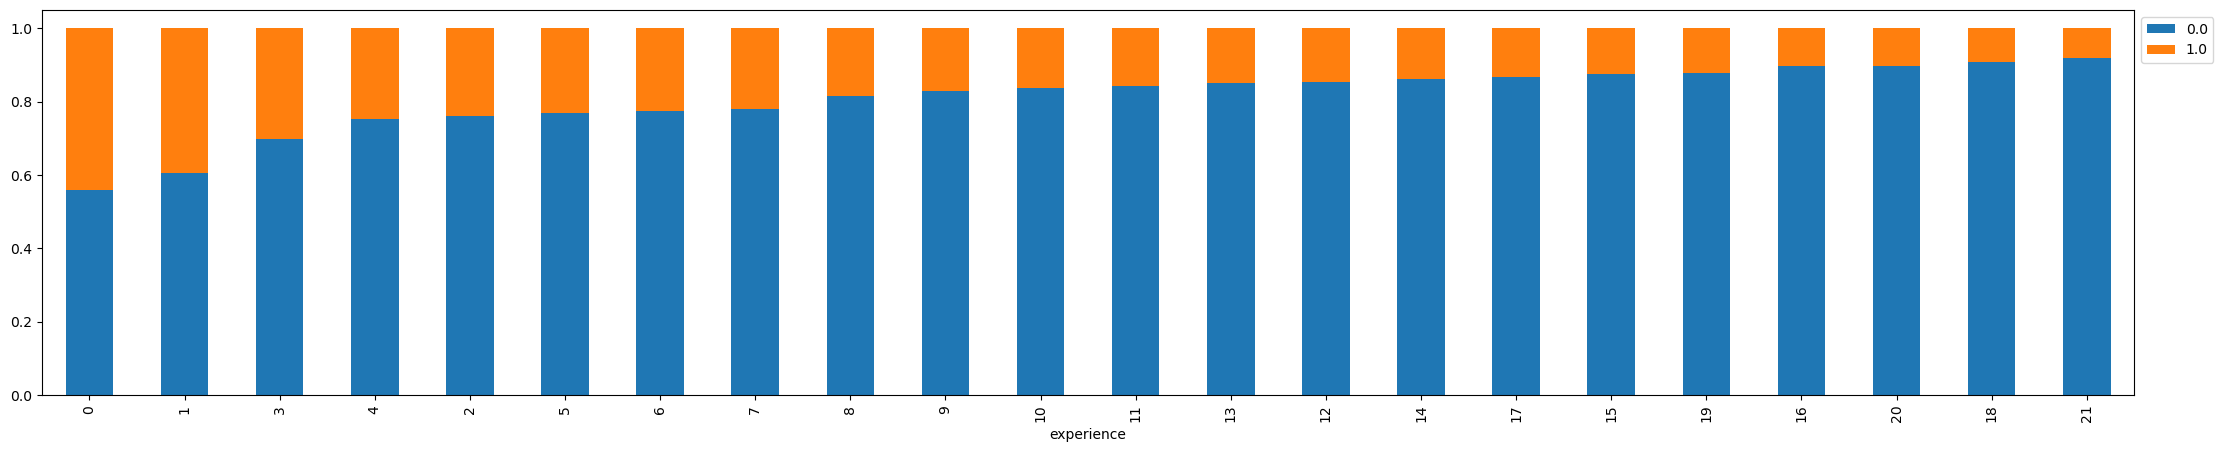

In [535]:
stacked_barplot(data=df, predictor='experience', target='target')

stacked_barplot(data=df, predictor='company_size', target='target')

target                 0.0   1.0    All
company_type                           
All                  10853  2367  13220
Pvt Ltd               7735  1676   9411
Public Sector          670   156    826
Unknown                638   142    780
Early Stage Startup    460   140    600
Funded Startup         856   139    995
NGO                    408    87    495
Other                   86    27    113
------------------------------------------------------------------------------------------------------------------------


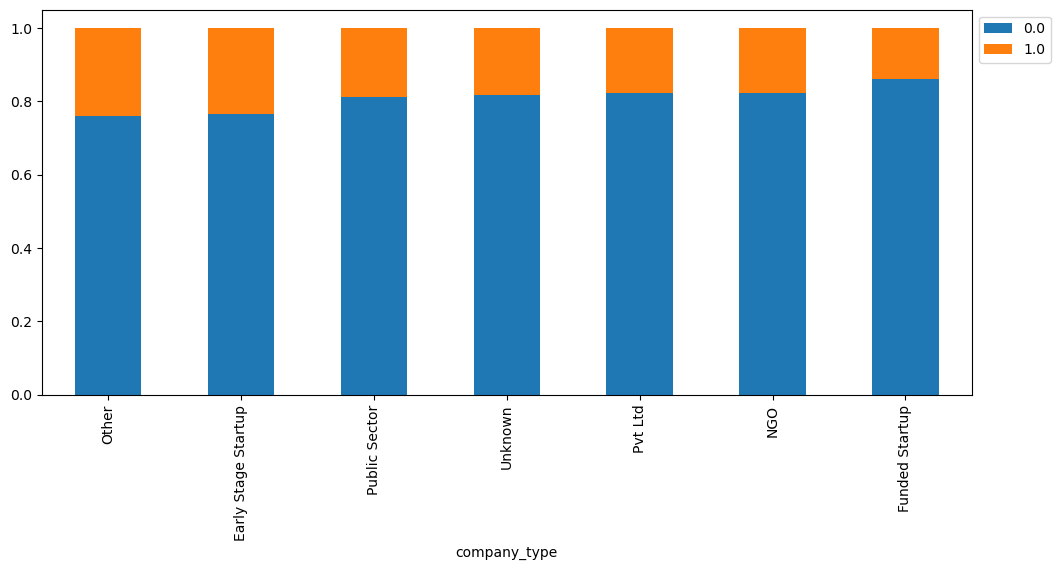

In [536]:
stacked_barplot(data=df, predictor='company_type', target='target')

target          0.0   1.0    All
last_new_job                    
All           10853  2367  13220
1              4886  1197   6083
2              1846   416   2262
>4             2241   311   2552
never           514   156    670
4               680   145    825
3               686   142    828
------------------------------------------------------------------------------------------------------------------------


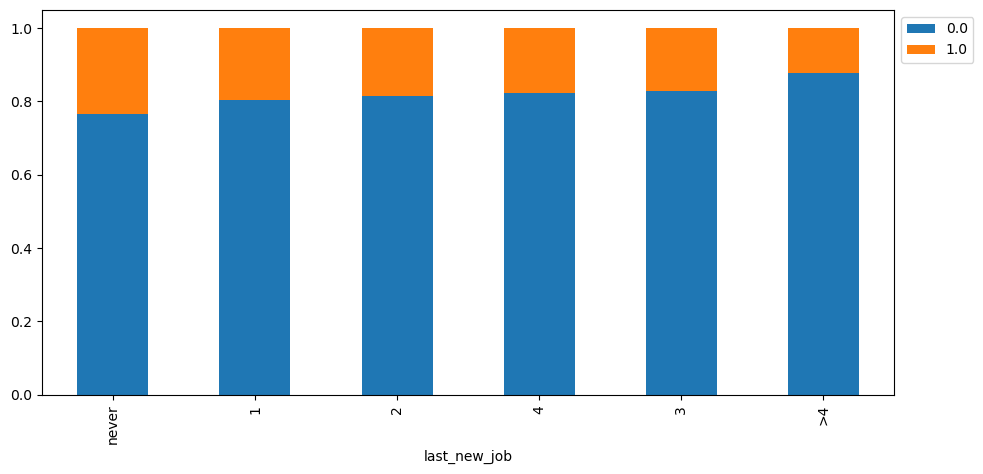

In [537]:
stacked_barplot(data=df, predictor='last_new_job', target='target')

Observations:
- After comparing the data all of them look to have some value towards our model so the only column I will be dropping as of now is training_hours
- Experience seems to be our best indicator as of now. 

### Consider numeric features - scaling, tranformation, binning

In [538]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,target
10807,0.913,Unknown,No relevent experience,no_enrollment,Phd,STEM,12,100-500,NGO,never,0.0
8167,0.926,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,11,1000-4999,Other,2,0.0
390,0.836,Male,No relevent experience,no_enrollment,Graduate,STEM,6,<10,Pvt Ltd,never,0.0
413,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,8,10-49,Pvt Ltd,1,1.0
9546,0.910,Male,Has relevent experience,no_enrollment,Masters,Humanities,14,>10000,Pvt Ltd,1,0.0
5239,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,0.0
1255,0.920,Female,No relevent experience,Full time course,Graduate,STEM,5,500-999,Pvt Ltd,1,0.0
15497,0.920,Male,No relevent experience,no_enrollment,Graduate,STEM,7,50-99,Unknown,1,0.0
4494,0.624,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,500-999,Pvt Ltd,1,0.0
2126,0.910,Unknown,Has relevent experience,no_enrollment,Masters,STEM,0,1000-4999,Pvt Ltd,1,0.0


Observations:
- I want to bin experience, to make the data work better
- I might encode gender and experience 
- No scaling is needed

In [539]:
df['experience'] = df['experience'].astype(int)

In [540]:
df['experience_group'] = pd.cut(df['experience'], bins=[0,4,9,14,21], labels=["Beginner","Intermediate","Advanced", "Expert"])

In [541]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,target,experience_group
4030,0.895,Male,Has relevent experience,no_enrollment,Masters,STEM,16,<10,Pvt Ltd,1,0.0,Expert
12788,0.762,Unknown,No relevent experience,no_enrollment,Graduate,STEM,0,1000-4999,Pvt Ltd,1,1.0,NaN
2865,0.926,Male,Has relevent experience,no_enrollment,Masters,STEM,21,>10000,Pvt Ltd,1,0.0,Expert
5934,0.920,Unknown,No relevent experience,Full time course,Masters,STEM,7,<10,Early Stage Startup,1,0.0,Intermediate
1938,0.624,Male,Has relevent experience,Full time course,Graduate,STEM,2,50-99,Pvt Ltd,never,1.0,Beginner
2289,0.920,Female,Has relevent experience,no_enrollment,Masters,Arts,4,50-99,NGO,4,0.0,Beginner
2276,0.910,Male,Has relevent experience,no_enrollment,Graduate,STEM,4,100-500,Pvt Ltd,1,0.0,Beginner
18663,0.910,Female,Has relevent experience,no_enrollment,Masters,STEM,9,50-99,Pvt Ltd,1,0.0,Intermediate
16943,0.579,Male,Has relevent experience,no_enrollment,Graduate,STEM,12,50-99,Pvt Ltd,>4,0.0,Advanced
16437,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,21,1000-4999,Pvt Ltd,>4,0.0,Expert


target              0.0   1.0    All
experience_group                    
All               10724  2265  12989
Intermediate       3064   810   3874
Beginner           1763   679   2442
Expert             3797   399   4196
Advanced           2100   377   2477
------------------------------------------------------------------------------------------------------------------------


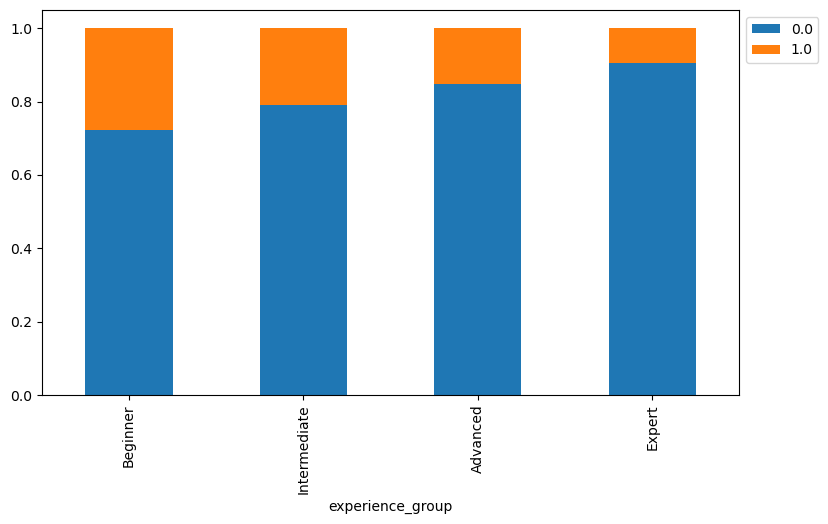

In [542]:
stacked_barplot(data=df, predictor='experience_group', target='target')

In [543]:
#clean up the data
df = df.drop(['experience'], axis=1)

### Encode any categorical variables

In [544]:
from sklearn import preprocessing
# Change relevant experience to 0 or 1
label_encoder = preprocessing.LabelEncoder()
df['relevent_experience']= label_encoder.fit_transform(df['relevent_experience'])

In [545]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,target,experience_group
10201,0.727,Male,0,no_enrollment,Graduate,STEM,50-99,Pvt Ltd,1,0.0,Beginner
12463,0.920,Male,0,no_enrollment,Graduate,STEM,50-99,Pvt Ltd,1,0.0,Advanced
13973,0.754,Male,0,no_enrollment,Masters,STEM,50-99,NGO,1,0.0,Beginner
8517,0.897,Unknown,0,Full time course,Graduate,STEM,50-99,Pvt Ltd,1,0.0,Beginner
3360,0.878,Unknown,1,no_enrollment,Graduate,Unknown,1000-4999,Pvt Ltd,>4,0.0,Advanced
9036,0.794,Female,0,no_enrollment,Graduate,STEM,100-500,Pvt Ltd,2,0.0,Expert
11592,0.624,Male,0,no_enrollment,Graduate,STEM,100-500,Pvt Ltd,3,0.0,Intermediate
8691,0.939,Male,0,no_enrollment,Graduate,STEM,100-500,Funded Startup,3,1.0,Intermediate
15243,0.767,Female,0,no_enrollment,Masters,STEM,10-49,Early Stage Startup,4,0.0,Advanced
13665,0.884,Male,0,no_enrollment,Graduate,STEM,50-99,Pvt Ltd,>4,0.0,Expert


In [546]:
df['last_new_job'].value_counts() 

last_new_job
1        6083
>4       2552
2        2262
3         828
4         825
never     670
Name: count, dtype: int64

In [547]:
df.loc[df['last_new_job'] == '>4', ['last_new_job']] = '5'
df.loc[df['last_new_job'] == 'never', ['last_new_job']] = '0'

In [548]:
#check if the values are good
df['last_new_job'].value_counts() 

last_new_job
1    6083
5    2552
2    2262
3     828
4     825
0     670
Name: count, dtype: int64

In [549]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,target,experience_group
7686,0.920,Unknown,0,no_enrollment,Masters,STEM,100-500,Public Sector,1,0.0,Expert
18719,0.789,Male,0,no_enrollment,Graduate,STEM,100-500,Public Sector,1,0.0,Advanced
7203,0.920,Male,0,no_enrollment,Graduate,STEM,>10000,Pvt Ltd,5,0.0,Expert
8236,0.920,Male,0,no_enrollment,Graduate,STEM,100-500,Pvt Ltd,5,0.0,Expert
3325,0.624,Unknown,0,no_enrollment,Masters,STEM,100-500,Pvt Ltd,5,1.0,Intermediate
16396,0.915,Male,0,no_enrollment,Graduate,STEM,10-49,Early Stage Startup,4,0.0,Intermediate
14902,0.939,Female,0,no_enrollment,Graduate,Other,50-99,Pvt Ltd,1,0.0,Intermediate
8809,0.887,Male,1,no_enrollment,Graduate,No Major,100-500,Pvt Ltd,5,0.0,Expert
8548,0.722,Male,0,no_enrollment,Graduate,Other,50-99,Funded Startup,2,0.0,Advanced
9214,0.920,Unknown,1,Full time course,Graduate,STEM,<10,Public Sector,1,0.0,Beginner


Observations:
- I need to do a few more columns, and I don't like the values in company size, so I will investigate that.

In [550]:
df['company_size'].value_counts() 

company_size
50-99        3083
100-500      2571
>10000       2019
10-49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

I do not really like these values

target          0.0   1.0    All
company_size                    
All           10853  2367  13220
50-99          2538   545   3083
100-500        2156   415   2571
>10000         1634   385   2019
10-49          1127   344   1471
<10            1084   224   1308
1000-4999      1128   200   1328
500-999         725   152    877
5000-9999       461   102    563
------------------------------------------------------------------------------------------------------------------------


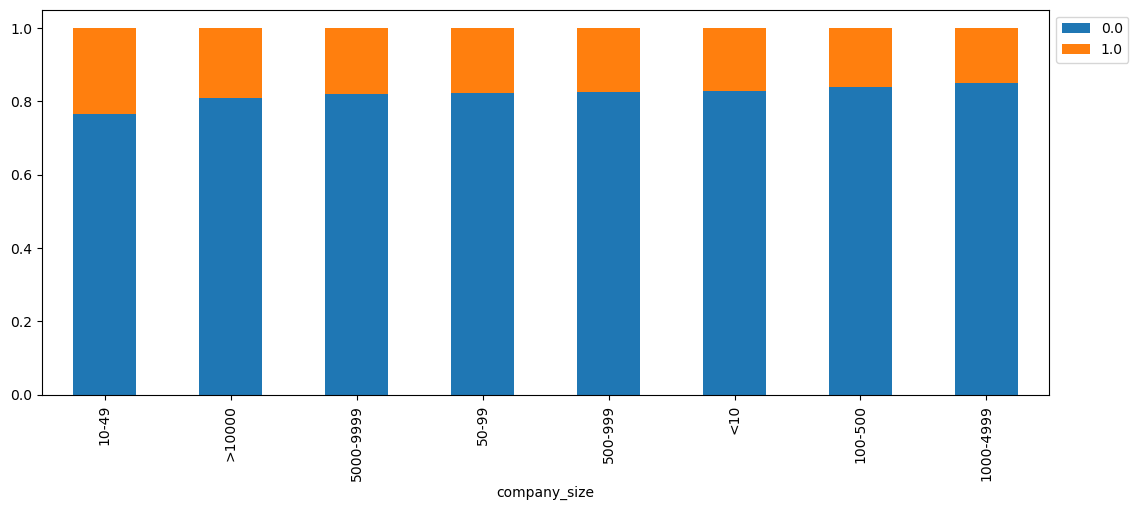

In [551]:
stacked_barplot(data=df, predictor='company_size', target='target')

In [552]:
# I feel like label encoding this column will help the model 
label_encoder = preprocessing.LabelEncoder()
df['company_size']= label_encoder.fit_transform(df['company_size'])

target          0.0   1.0    All
company_size                    
All           10853  2367  13220
3              2538   545   3083
1              2156   415   2571
7              1634   385   2019
0              1127   344   1471
6              1084   224   1308
2              1128   200   1328
4               725   152    877
5               461   102    563
------------------------------------------------------------------------------------------------------------------------


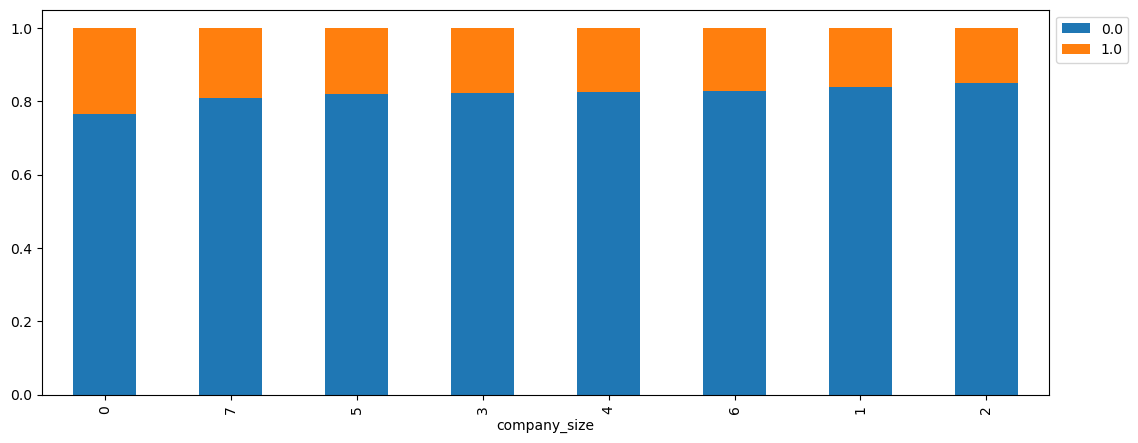

In [553]:
stacked_barplot(data=df, predictor='company_size', target='target')

In [554]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,target,experience_group
18189,0.897,Male,0,no_enrollment,Graduate,STEM,6,Early Stage Startup,1,0.0,Intermediate
7183,0.754,Male,0,no_enrollment,Graduate,STEM,3,Early Stage Startup,1,0.0,Beginner
12018,0.920,Unknown,0,no_enrollment,Graduate,Arts,6,Pvt Ltd,5,0.0,Expert
6325,0.924,Male,0,no_enrollment,Graduate,STEM,3,Pvt Ltd,1,0.0,Expert
18866,0.878,Male,0,no_enrollment,Graduate,STEM,3,Pvt Ltd,3,0.0,Intermediate
6700,0.939,Unknown,1,Full time course,Masters,STEM,7,Pvt Ltd,4,0.0,Expert
2410,0.920,Male,0,no_enrollment,Graduate,No Major,3,Funded Startup,1,0.0,Expert
9670,0.920,Male,0,no_enrollment,Graduate,Business Degree,6,Pvt Ltd,1,0.0,Intermediate
13128,0.698,Male,0,Full time course,Graduate,STEM,0,Funded Startup,1,0.0,Intermediate
12937,0.920,Unknown,0,no_enrollment,Graduate,STEM,1,Pvt Ltd,1,0.0,Intermediate


Encode the rest of the categorical data

In [555]:
label_encoder = preprocessing.LabelEncoder()
df['gender']= label_encoder.fit_transform(df['gender'])

In [556]:
label_encoder = preprocessing.LabelEncoder()
df['enrolled_university']= label_encoder.fit_transform(df['enrolled_university'])

In [557]:
label_encoder = preprocessing.LabelEncoder()
df['education_level']= label_encoder.fit_transform(df['education_level'])

In [558]:
label_encoder = preprocessing.LabelEncoder()
df['major_discipline']= label_encoder.fit_transform(df['major_discipline'])

In [559]:
label_encoder = preprocessing.LabelEncoder()
df['company_type']= label_encoder.fit_transform(df['company_type'])

In [560]:
label_encoder = preprocessing.LabelEncoder()
df['experience_group']= label_encoder.fit_transform(df['experience_group'])

In [561]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,target,experience_group
8809,0.887,1,1,2,0,3,1,5,5,0.0,2
13968,0.893,1,0,1,0,5,1,5,3,0.0,2
2974,0.624,1,0,2,1,6,0,5,5,1.0,0
3083,0.939,1,0,2,0,5,1,5,5,0.0,0
15844,0.624,1,0,2,0,5,3,5,1,1.0,3
10220,0.804,1,0,2,2,5,2,5,1,1.0,0
17269,0.884,3,0,2,2,2,3,5,1,0.0,3
18528,0.682,1,1,2,0,5,1,2,0,0.0,1
12100,0.527,3,1,0,0,5,3,5,1,0.0,4
16879,0.920,1,0,2,0,5,3,1,1,0.0,2


Now the data is ready for our model.

### Review dataframe to ensure it is ready from building the model

In [562]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13220 entries, 1 to 19156
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  13220 non-null  float64
 1   gender                  13220 non-null  int64  
 2   relevent_experience     13220 non-null  int64  
 3   enrolled_university     13220 non-null  int64  
 4   education_level         13220 non-null  int64  
 5   major_discipline        13220 non-null  int64  
 6   company_size            13220 non-null  int64  
 7   company_type            13220 non-null  int64  
 8   last_new_job            13220 non-null  object 
 9   target                  13220 non-null  float64
 10  experience_group        13220 non-null  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 1.2+ MB


Need to fix data types 

In [563]:
DTypeFix = ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_type', 'last_new_job','company_size', 'target','experience_group']
# Convert them all to category
df[DTypeFix] = df[DTypeFix].astype('category')

In [564]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13220 entries, 1 to 19156
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   city_development_index  13220 non-null  float64 
 1   gender                  13220 non-null  category
 2   relevent_experience     13220 non-null  category
 3   enrolled_university     13220 non-null  category
 4   education_level         13220 non-null  category
 5   major_discipline        13220 non-null  category
 6   company_size            13220 non-null  category
 7   company_type            13220 non-null  category
 8   last_new_job            13220 non-null  category
 9   target                  13220 non-null  category
 10  experience_group        13220 non-null  category
dtypes: category(10), float64(1)
memory usage: 337.9 KB


In [565]:
df.sample(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,target,experience_group
2798,0.887,1,0,2,0,5,7,5,5,1.0,2
12071,0.897,1,0,2,2,5,3,5,1,0.0,3
11811,0.926,0,1,1,0,5,7,5,1,0.0,1
16148,0.884,1,0,2,2,5,0,4,5,0.0,2
3406,0.897,1,1,1,2,5,2,6,1,0.0,1
8337,0.920,1,1,1,1,6,6,5,3,1.0,1
8593,0.920,1,0,2,0,5,5,5,3,0.0,2
14902,0.939,0,0,2,0,4,3,5,1,0.0,3
16689,0.743,1,0,1,0,5,3,5,1,0.0,3
2570,0.893,1,0,0,0,5,6,5,1,0.0,3


In [566]:
#create a copy
modelready = df.copy()

Feature Engineering summary: 

To start our feature engineering, we did not need to do anything to the city_development_index as it was already min/max scaled. One thing that I feel off about is label encoding every categorical value; however, I feel like that is better than using hot one encoding. I decided to drop training hours, as they had very little impact on the target. I then changed the experience into more applicable values for the model. After this, I realized that I missed data inconsistencies in some of the columns, so I decided to fix those. Then the only thing left to do was fix the company size and encode the categorical data. 

## OPTIONAL - Model Building 

In [567]:
#see if ints work
modelready.DTypeFix = ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_type', 'last_new_job','company_size', 'target','experience_group']
# Convert them all to category
df[DTypeFix] = df[DTypeFix].astype('int')

Train set performance:
   Accuracy    Recall  Precision        F1
0  0.826561  0.165759      0.548  0.254529
Test set performance:
   Accuracy    Recall  Precision        F1
0  0.828795  0.170868   0.583732  0.264355


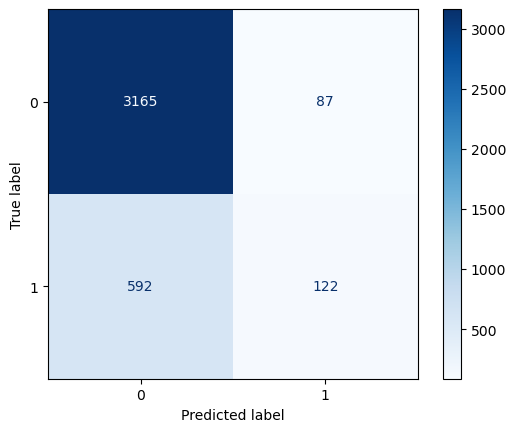

In [568]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

# create training and test data
X = df.drop('target',axis=1)   
Y = df['target']   

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)


# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics, based on the threshold specified, to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # predicting using the independent variables
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    pred = np.round(pred_thres)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf


# Fit the model on training set
model = LogisticRegression(solver="liblinear", random_state=1)
lg = model.fit(x_train, y_train)

# predict on test set
y_predict = model.predict(x_test)

# check the training set performance
log_reg_model_train_perf = model_performance_classification_sklearn_with_threshold(lg, x_train, y_train)
print("Train set performance:")
print(log_reg_model_train_perf)

# check the test set performance
log_reg_model_test_perf = model_performance_classification_sklearn_with_threshold(lg, x_test, y_test)
print("Test set performance:")
print(log_reg_model_test_perf)

# Plot confusion matrix using the new method
cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.show()

Observations:
- The model has 82% accuracy
- We have more false negatives and very few false positives, this is good for our model because we would rather be wrong that they are not looking for a job than looking for a job. 
- We have a low count for our true positives and false positives
- There are a lot of true negatives predicted correctly